# Material Stock and Embodied Carbon Projections

**Note:** the core analysis only uses A1 to A3 data.

## Import libraries

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

In [2]:
# Set the default font family for all plots
plt.rcParams['font.family'] = 'Calibri'  # Or any other font you prefer
# ['sans-serif'] was previously selected.

## Import Data

In [3]:
wblca_meta_data = pd.read_excel('./Input Data/buildings_metadata_02-21-2025.xlsx')

In [4]:
# Load the CSV file into a DataFrame
wblca_results_full = pd.read_excel('./Input Data/full_lca_results_02-21-2025.xlsx')

In [5]:
# Remove rows where inv_mass or gwp is 0 or NaN
wblca_results_full = wblca_results_full[
    (~wblca_results_full['inv_mass'].isin([0, np.nan])) &
    (~wblca_results_full['gwp'].isin([0, np.nan]))
].reset_index(drop=True)

In [6]:
print(wblca_meta_data['bldg_prim_use'].unique())

['Residential: Multifamily (5 or more units)' 'Office' 'Education'
 'Healthcare' 'Warehouse and Storage' 'Industrial' 'Public Assembly'
 'Parking' 'Public Order and Safety' 'Lodging' 'Laboratory' 'Mercantile'
 'Transportation Hub' 'Other' 'Religious Worship' 'Food Service']


## Data Pre-Processing

### Add A1-A3 level MUI and ECI to `wblca_meta_data`

In [7]:
# Filter the dataframe for Life Cycle Stage "A1-A3"
wblca_results_full_a1_to_a3 = wblca_results_full[wblca_results_full['life_cycle_stage'] == 'A1-A3']
wblca_results_full_a1_to_a3['project_index'] = wblca_results_full_a1_to_a3['project_index'].astype(str)

# Aggregate inv_mass and gwp by project_index
aggregated_df = wblca_results_full_a1_to_a3.groupby('project_index').agg(
    total_mass_a1_to_a3=('inv_mass', 'sum'),  # Sum inv_mass
    total_gwp_a1_to_a3=('gwp', 'sum')        # Sum gwp
).reset_index()

aggregated_df['project_index'] = aggregated_df['project_index'].astype(str)
wblca_meta_data['project_index'] = wblca_meta_data['project_index'].astype(str)

# Step 2: Merge aggregated data with bldg_cfa from metadata
aggregated_df = aggregated_df.merge(
    wblca_meta_data[['project_index', 'bldg_cfa']], on='project_index', how='left'
)

# Step 3: Compute Material Use Intensity (mui) and Embodied Carbon Intensity (eci)
aggregated_df['total_mui_a1_to_a3'] = np.where(
    aggregated_df['bldg_cfa'] != 0, aggregated_df['total_mass_a1_to_a3'] / aggregated_df['bldg_cfa'], np.nan
)

aggregated_df['total_eci_a1_to_a3'] = np.where(
    aggregated_df['bldg_cfa'] != 0, aggregated_df['total_gwp_a1_to_a3'] / aggregated_df['bldg_cfa'], np.nan
)

# ✅ Drop 'bldg_cfa' after calculations
aggregated_df = aggregated_df.drop(columns=['bldg_cfa'])

# Merge the aggregated data with the wblca_meta_data dataframe
wblca_meta_data = pd.merge(wblca_meta_data, aggregated_df, on='project_index', how='left')

# Display the merged dataframe
wblca_meta_data.head()


C:\Users\ashtiani\AppData\Local\Temp\ipykernel_15828\3711530083.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wblca_results_full_a1_to_a3['project_index'] = wblca_results_full_a1_to_a3['project_index'].astype(str)


,project_index,site_country,site_region,site_state_province,site_clim_zone,bldg_code_year,bldg_energy_code_year,bldg_compl_year,bldg_proj_type,bldg_ibc_type,...,api_a_to_c_cfa,sfpi_a_to_c_cfa,odpi_a_to_c_cfa,nredi_a_to_c_cfa,ec_per_occupant_a_to_c,ec_per_res_unit_a_to_c,total_mass_a1_to_a3,total_gwp_a1_to_a3,total_mui_a1_to_a3,total_eci_a1_to_a3
0,1,Canada,Canada,British Columbia,Can. 4 (<3000 HDD),NaN,NaN,NaN,New Construction,Type I-B,...,2.137669,34.967106,4.923251e-06,5899.044057,10528.599868,75450.261252,7.653859e+07,2.254295e+07,1578.115339,464.803054
1,2,United States,Eastern,NaN,Can. 7B (6000-6999 HDD),2018.0,2018.0,2022.0,New Construction,Type I-A,...,2.181800,35.413576,1.954153e-05,3392.982240,NaN,NaN,4.328714e+08,1.017477e+08,2164.356905,508.738385
2,3,United States,Pacific Southwest,NaN,Zone 1A (Very Hot Humid),2012.0,2015.0,2024.0,New Construction,Type II-B,...,1.997141,33.740725,3.382413e-06,6539.973610,965.577432,NaN,4.755715e+06,1.226292e+06,1829.121246,471.650627
3,4,United States,South Eastern,NaN,Zone 1A (Very Hot Humid),2020.0,2020.0,NaN,New Construction,Type I-B,...,1.380832,21.952562,-7.195596e-08,3952.997909,4312.387153,NaN,2.218759e+07,5.416885e+06,1232.643691,300.938069
4,5,United States,Pacific Southwest,NaN,Zone 1A (Very Hot Humid),2012.0,2015.0,2024.0,New Construction,Type II-B,...,2.307666,34.205557,3.236020e-06,6718.389264,2204.644740,NaN,5.182974e+06,1.855065e+06,1346.226899,481.835151


### Exclude outlier projects
We use a z-score criteria here to detect outliers with this conditions:
* Due to high variability, use log-transformed data to detect outliers.
* If either the absolute z-score values for `total_mui_a1_to_a3` OR `total_eci_a1_to_a1` are greater than 3, the `project_index` is excluded.

In [8]:
# Creating a copy to avoid modifying the original dataframe
wblca_meta_data_log = wblca_meta_data.copy()

# Selecting relevant features
features = ['total_mui_a1_to_a3', 'total_eci_a1_to_a3']

# Ensure numeric data and replace zeros (log issues)
for col in features:
    wblca_meta_data_log[col] = pd.to_numeric(wblca_meta_data_log[col], errors='coerce')
    wblca_meta_data_log[col] = wblca_meta_data_log[col].replace(0, np.nan)  # Avoid log(0)

# Create separate log-transformed columns
for col in features:
    wblca_meta_data_log[f'log_{col}'] = np.log1p(wblca_meta_data_log[col])  # log1p to handle zeros

# Compute mean and standard deviation for z-score
mean_vals = wblca_meta_data_log[[f'log_{col}' for col in features]].mean()
std_vals = wblca_meta_data_log[[f'log_{col}' for col in features]].std()

# Compute z-score for log-transformed values
for col in features:
    wblca_meta_data_log[f'z_score_log_{col}'] = (wblca_meta_data_log[f'log_{col}'] - mean_vals[f'log_{col}']) / std_vals[f'log_{col}']

# Identify outliers where any absolute z-score is greater than 3
outlier_df = wblca_meta_data_log[
    (wblca_meta_data_log['z_score_log_total_mui_a1_to_a3'].abs() > 3) | 
    (wblca_meta_data_log['z_score_log_total_eci_a1_to_a3'].abs() > 3)
]

# Filter wblca_meta_data to exclude these project_index values
wblca_meta_data = wblca_meta_data[
    ~wblca_meta_data['project_index'].isin(outlier_df['project_index'])
]

outlier_df.head(5)


,project_index,site_country,site_region,site_state_province,site_clim_zone,bldg_code_year,bldg_energy_code_year,bldg_compl_year,bldg_proj_type,bldg_ibc_type,...,ec_per_occupant_a_to_c,ec_per_res_unit_a_to_c,total_mass_a1_to_a3,total_gwp_a1_to_a3,total_mui_a1_to_a3,total_eci_a1_to_a3,log_total_mui_a1_to_a3,log_total_eci_a1_to_a3,z_score_log_total_mui_a1_to_a3,z_score_log_total_eci_a1_to_a3
25,26,United States,Pacific Southwest,California,Zone 2B (Hot Dry),NaN,NaN,NaN,New Construction,Type II-B,...,18189.484872,NaN,3.900746e+07,1.061793e+07,4906.598170,1335.589089,8.498540,7.197876,3.296901,2.847190
142,143,United States,Pacific Northwest,Oregon,Zone 4C (Mixed Marine),2019.0,2021.0,2024.0,New Construction,Type I-B,...,1101.455803,NaN,2.921177e+06,1.886486e+06,129.830090,83.843805,4.873899,4.440812,-4.309799,-3.169046
143,144,Canada,Canada,British Columbia,Zone 4C (Mixed Marine),2018.0,NaN,2025.0,New Construction,NaN,...,NaN,NaN,5.725126e+06,1.475869e+06,269.417712,69.452680,5.599968,4.254941,-2.786066,-3.574637
159,160,United States,Pacific Northwest,Washington,Zone 4C (Mixed Marine),2012.0,2012.0,2022.0,New Construction,Type I-B,...,NaN,NaN,1.986205e+07,1.398645e+07,2739.593494,1929.165151,7.915930,7.565361,2.074231,3.649084


In [9]:
# Filter wblca_meta_data to exclude rows where project_index is in outlier_df
wblca_meta_data = wblca_meta_data[
    ~wblca_meta_data['project_index'].isin(outlier_df['project_index'])
]

In [10]:
# Filter your dataframe based on 'proj_type'
wblca_meta_data_new_construction = wblca_meta_data[wblca_meta_data['bldg_proj_type'] == 'New Construction']

# Get descriptive statistics for filtered data
wblca_meta_data_new_construction.describe()

,bldg_code_year,bldg_energy_code_year,bldg_compl_year,bldg_cfa,bldg_gfa,bldg_park_gfa,bldg_added_gfa,bldg_renovated_gfa,bldg_occupants,bldg_res_units,...,api_a_to_c_cfa,sfpi_a_to_c_cfa,odpi_a_to_c_cfa,nredi_a_to_c_cfa,ec_per_occupant_a_to_c,ec_per_res_unit_a_to_c,total_mass_a1_to_a3,total_gwp_a1_to_a3,total_mui_a1_to_a3,total_eci_a1_to_a3
count,218.000000,205.000000,179.000000,239.000000,239.000000,68.000000,0.0,0.0,188.000000,39.000000,...,239.000000,239.000000,2.390000e+02,239.000000,188.000000,39.000000,2.390000e+02,2.390000e+02,239.000000,239.000000
mean,2016.110092,2016.068293,2022.469274,19664.811715,16802.133891,10061.470588,NaN,NaN,2294.710968,221.974359,...,2.247409,29.051543,3.696163e-03,5066.576667,6007.032042,53043.533427,2.198813e+07,7.096021e+06,1118.237303,394.025947
std,2.887569,3.215346,2.675924,25515.869635,22149.554732,11498.017385,NaN,NaN,6702.391674,169.165831,...,1.242268,19.209744,4.181659e-02,2757.553732,7702.071069,70586.777683,3.754789e+07,1.031554e+07,463.534665,165.461230
min,2006.000000,2004.000000,2010.000000,130.000000,0.000000,150.000000,NaN,NaN,8.000000,3.000000,...,0.560692,3.841691,-1.149782e-07,974.598888,40.411515,9613.786138,1.997853e+05,5.710250e+04,268.812897,115.344964
25%,2015.000000,2015.000000,2021.000000,3800.000000,3575.000000,2912.500000,NaN,NaN,503.000000,100.500000,...,1.425417,20.296976,4.745325e-06,3147.827694,2411.112253,31431.530013,3.530530e+06,1.412406e+06,770.855621,267.562442
50%,2016.000000,2016.000000,2023.000000,11100.000000,9600.000000,6050.000000,NaN,NaN,1049.500000,186.000000,...,2.015914,26.095116,1.197502e-05,4656.595726,4155.776182,39947.214273,1.061798e+07,3.700059e+06,1071.152546,360.590479
75%,2018.000000,2018.000000,2024.000000,24500.000000,21600.000000,14700.000000,NaN,NaN,2250.000000,330.000000,...,2.634580,34.750052,2.970320e-05,6560.442563,6692.626114,53577.160923,2.490592e+07,7.974636e+06,1385.551081,492.932386
max,2023.000000,2023.000000,2030.000000,200000.000000,195500.000000,62000.000000,NaN,NaN,84372.000000,631.000000,...,8.208654,272.591168,5.763326e-01,27819.606629,63540.331927,467395.683829,4.328714e+08,1.017477e+08,2861.591379,1028.926561


## Merging

In [11]:
wblca_results_full['project_index'] = wblca_results_full['project_index'].astype(str)
wblca_meta_data['project_index'] = wblca_meta_data['project_index'].astype(str)

# Perform a left join on the 'project_index' column
merged_df = pd.merge(wblca_results_full, wblca_meta_data, on="project_index", how="left")

# Display the first few rows of the merged dataframe to confirm
merged_df.head(5)

,project_index,omniclass_element,mat_group,mat_type,mat_csi_division,tally_revit_building_element,tally_material_group,oneclick_omniclass,oneclick_resource_type,service_life,...,api_a_to_c_cfa,sfpi_a_to_c_cfa,odpi_a_to_c_cfa,nredi_a_to_c_cfa,ec_per_occupant_a_to_c,ec_per_res_unit_a_to_c,total_mass_a1_to_a3,total_gwp_a1_to_a3,total_mui_a1_to_a3,total_eci_a1_to_a3
0,1,Substructure,Steel,Steel sheet,05 - Metals,Substructure,Metal,NaN,NaN,45,...,2.137669,34.967106,0.000005,5899.044057,10528.599868,75450.261252,7.653859e+07,2.254295e+07,1578.115339,464.803054
1,1,Substructure,Coatings,Coatings - other,05 - Metals,Substructure,Metal Coating,NaN,NaN,50,...,2.137669,34.967106,0.000005,5899.044057,10528.599868,75450.261252,7.653859e+07,2.254295e+07,1578.115339,464.803054
2,1,Substructure,Concrete,Ready mix NW 4000,03 - Concrete,Superstructure,Concrete,NaN,NaN,60,...,2.137669,34.967106,0.000005,5899.044057,10528.599868,75450.261252,7.653859e+07,2.254295e+07,1578.115339,464.803054
3,1,Substructure,Steel,Rebar and reinforcement,03 - Concrete,Superstructure,Metal,NaN,NaN,60,...,2.137669,34.967106,0.000005,5899.044057,10528.599868,75450.261252,7.653859e+07,2.254295e+07,1578.115339,464.803054
4,1,Substructure,Concrete,Ready mix NW 4000,03 - Concrete,Superstructure,Concrete,NaN,NaN,60,...,2.137669,34.967106,0.000005,5899.044057,10528.599868,75450.261252,7.653859e+07,2.254295e+07,1578.115339,464.803054


## Filtering data

In [12]:
merged_df = merged_df[merged_df['bldg_proj_type'] == "New Construction"]


In [13]:
merged_df = merged_df[merged_df['life_cycle_stage'] == "A1-A3"]


In [14]:
# List of columns to keep
columns_to_keep = [
    "project_index", "omniclass_element", "mat_group", "mat_type", "mat_csi_division",
    "tally_revit_building_element", "tally_material_group", "oneclick_omniclass",
    "oneclick_resource_type", "life_cycle_stage", "inv_mass", "gwp", "str_sys_summary", "bldg_cfa",
    "bldg_prim_use", "lca_software", "lca_phys_scope"
]

# Filter the dataframe to keep only the specified columns
merged_df = merged_df[columns_to_keep]

In [15]:
print(merged_df['bldg_prim_use'].unique())

['Residential: Multifamily (5 or more units)' 'Office' 'Education'
 'Healthcare' 'Warehouse and Storage' 'Industrial' 'Public Assembly'
 'Parking' 'Public Order and Safety' 'Laboratory' 'Transportation Hub'
 'Lodging' 'Mercantile' 'Food Service']


## Data re-structuring and categorization

Recategorize building use type categories.

In [16]:
import pandas as pd

# Filter the dataframe to include only rows where 'lca_phys_scope' is 'BSECF'
bsecf_df = merged_df[merged_df['lca_phys_scope'] == 'BSECF']

# Group by 'bldg_prim_use' and count unique 'project_index' values for each category in the filtered dataframe
unique_bsecf_project_counts_per_use = bsecf_df.groupby('bldg_prim_use')['project_index'].nunique()

# Group by 'bldg_prim_use' and count unique 'project_index' values for each category in the original dataframe
unique_project_counts_per_use = merged_df.groupby('bldg_prim_use')['project_index'].nunique()

# Merge the results to compare them side by side
combined_counts = pd.DataFrame({
    'Total Unique Projects': unique_project_counts_per_use,
    'Unique Projects (BSECF)': unique_bsecf_project_counts_per_use
})

# Fill missing values with 0 in 'Unique Projects (BSECF)' column after merging, since not all categories might have BSECF data
combined_counts['Unique Projects (BSECF)'] = combined_counts['Unique Projects (BSECF)'].fillna(0)

# Sort the DataFrame based on 'Total Unique Projects' in descending order
combined_counts = combined_counts.sort_values('Total Unique Projects', ascending=False)

# Display the sorted combined counts
combined_counts


,Total Unique Projects,Unique Projects (BSECF)
bldg_prim_use,,
Education,46,33.0
Residential: Multifamily (5 or more units),43,34.0
Office,42,21.0
Public Assembly,27,21.0
Warehouse and Storage,21,12.0
Laboratory,18,5.0
Healthcare,13,11.0
Public Order and Safety,10,8.0
Transportation Hub,8,3.0


Creating a new 'wedge_bldg_prim_use' column where if project counts for BSECF scope is less than 5, the building use is assigned as 'Other'.

In [17]:
import pandas as pd

# Filter the dataframe to include only rows where 'lca_phys_scope' is 'BSECF'
bsecf_df = merged_df[merged_df['lca_phys_scope'] == 'BSECF']

# Group by 'bldg_prim_use' and count unique 'project_index' values for each category in the filtered dataframe
unique_bsecf_project_counts_per_use = bsecf_df.groupby('bldg_prim_use')['project_index'].nunique()

# Group by 'bldg_prim_use' and count unique 'project_index' values for each category in the original dataframe
unique_project_counts_per_use = merged_df.groupby('bldg_prim_use')['project_index'].nunique()

# Merge the results to compare them side by side
combined_counts = pd.DataFrame({
    'Total Unique Projects': unique_project_counts_per_use,
    'Unique Projects (BSECF)': unique_bsecf_project_counts_per_use
})

# Fill missing values with 0 in 'Unique Projects (BSECF)' column after merging
combined_counts['Unique Projects (BSECF)'] = combined_counts['Unique Projects (BSECF)'].fillna(0)

# Sort the DataFrame based on 'Total Unique Projects' in descending order
combined_counts = combined_counts.sort_values('Total Unique Projects', ascending=False)

# Create a dictionary to map 'bldg_prim_use' values to 'wedge_bldg_prim_use'
wedge_mapping = {
    bldg_prim_use: bldg_prim_use if count >= 5 else 'Other'
    for bldg_prim_use, count in combined_counts['Unique Projects (BSECF)'].items()
}

# Add the 'wedge_bldg_prim_use' column to the original dataframe
merged_df['wedge_bldg_prim_use'] = merged_df['bldg_prim_use'].map(wedge_mapping)

# Display the updated merged_df to verify the new column
merged_df[['bldg_prim_use', 'wedge_bldg_prim_use']].head()


,bldg_prim_use,wedge_bldg_prim_use
0,Residential: Multifamily (5 or more units),Residential: Multifamily (5 or more units)
1,Residential: Multifamily (5 or more units),Residential: Multifamily (5 or more units)
2,Residential: Multifamily (5 or more units),Residential: Multifamily (5 or more units)
3,Residential: Multifamily (5 or more units),Residential: Multifamily (5 or more units)
4,Residential: Multifamily (5 or more units),Residential: Multifamily (5 or more units)


In [18]:
import pandas as pd

# Filter the dataframe to include only rows where 'lca_phys_scope' is 'BSECF'
bsecf_df = merged_df[merged_df['lca_phys_scope'] == 'BSECF']

# Group by 'wedge_bldg_prim_use' and count unique 'project_index' values for each category in the filtered dataframe
unique_bsecf_project_counts_per_use = bsecf_df.groupby('wedge_bldg_prim_use')['project_index'].nunique()

# Group by 'wedge_bldg_prim_use' and count unique 'project_index' values for each category in the original dataframe
unique_project_counts_per_use = merged_df.groupby('wedge_bldg_prim_use')['project_index'].nunique()

# Merge the results to compare them side by side
combined_counts = pd.DataFrame({
    'Total Unique Projects': unique_project_counts_per_use,
    'Unique Projects (BSECF)': unique_bsecf_project_counts_per_use
})

# Fill missing values with 0 in 'Unique Projects (BSECF)' column after merging, since not all categories might have BSECF data
combined_counts['Unique Projects (BSECF)'] = combined_counts['Unique Projects (BSECF)'].fillna(0)

# Sort the DataFrame based on 'Total Unique Projects' in descending order
combined_counts = combined_counts.sort_values('Total Unique Projects', ascending=False)

# Display the sorted combined counts
combined_counts


,Total Unique Projects,Unique Projects (BSECF)
wedge_bldg_prim_use,,
Education,46,33
Residential: Multifamily (5 or more units),43,34
Office,42,21
Public Assembly,27,21
Warehouse and Storage,21,12
Other,19,7
Laboratory,18,5
Healthcare,13,11
Public Order and Safety,10,8


## Calculated fields

In [19]:
# Assuming merged_df is already defined and contains the relevant columns

# Calculate the new column "mui"
merged_df['mui'] = merged_df['inv_mass'] / merged_df['bldg_cfa']

# Calculate the new column "eci"
merged_df['eci'] = merged_df['gwp'] / merged_df['bldg_cfa']

# Calculate the new column "gwp_factor", handling division by zero
merged_df['gwp_factor'] = np.divide(merged_df['gwp'], 
                                                     merged_df['inv_mass'], 
                                                     out=np.nan * np.ones_like(merged_df['gwp']),
                                                     where=merged_df['inv_mass'] != 0)

# Check the first few rows to confirm the calculation
print(merged_df[['inv_mass', 'bldg_cfa', 'mui', 
                 'eci', 
                  'gwp_factor']].head())


        inv_mass  bldg_cfa        mui       eci  gwp_factor
0   14953.126660   48500.0   0.308312  0.718367    2.330000
1      29.247803   48500.0   0.000603  0.006453   10.700000
2  853083.412800   48500.0  17.589349  2.804880    0.159465
3   18030.252870   48500.0   0.371758  0.710057    1.910000
4  254305.012100   48500.0   5.243402  0.836138    0.159465


## Material category mappings and flows.

Flow based on counts.

By mass intensity when looking at all buildings as being one.

In [20]:
import pandas as pd

# Assuming merged_df is already loaded and filtered for the specific life cycle stage and project type
filtered_df = merged_df

# Step 1: Group by 'project_index' and 'mat_group', then sum the 'mui'
group_sums = filtered_df.groupby(['project_index', 'mat_group'])['mui'].sum().reset_index()

# Step 2: Calculate mean values across all projects for each 'mat_group'
group_means = group_sums.groupby('mat_group')['mui'].mean().reset_index()

# Displaying the results to check the mean sums
print(group_means)

                    mat_group         mui
0           Acoustic ceilings    2.038968
1      Adhesives and sealants    0.192111
2      Air and vapor barriers    0.749660
3                    Aluminum    3.132470
4        Applied fireproofing   11.260444
5                    Cladding    4.215852
6                    Coatings    0.664816
7                    Concrete  899.704177
8            Doors and frames    1.456558
9           Flooring and tile    2.440487
10                    Glazing    4.765673
11                     Gypsum   34.096931
12                 Insulation    6.439908
13                    Masonry   59.084054
14                      Other    0.601222
15               Other metals    0.329790
16  Roofing and waterproofing    2.025375
17                      Steel   84.350671
18       Synthetic composites    1.056784
19             Wall coverings    0.051531
20         Windows and frames    1.563032
21        Wood and composites   31.573672


By GWP intensity when looking at all buildings being just one.

In [21]:
# Assuming merged_df is already loaded and filtered for the specific life cycle stage and project type
filtered_df = merged_df

# Step 1: Group by 'project_index' and 'mat_group', then sum the 'eci'
group_sums = filtered_df.groupby(['project_index', 'mat_group'])['eci'].sum().reset_index()

# Step 2: Calculate median values across all projects for each 'mat_group'
group_means = group_sums.groupby('mat_group')['eci'].mean().reset_index()

# Displaying the results to check the median sums
print(group_means)

                    mat_group         eci
0           Acoustic ceilings    3.449017
1      Adhesives and sealants    0.393866
2      Air and vapor barriers    1.283367
3                    Aluminum   22.555740
4        Applied fireproofing   13.075391
5                    Cladding    9.037422
6                    Coatings    3.676743
7                    Concrete  149.173079
8            Doors and frames    3.766993
9           Flooring and tile    3.186193
10                    Glazing    8.013864
11                     Gypsum    8.862560
12                 Insulation   31.197478
13                    Masonry   10.952455
14                      Other    0.637491
15               Other metals    0.863943
16  Roofing and waterproofing    3.507371
17                      Steel  128.755627
18       Synthetic composites    3.276712
19             Wall coverings    0.403965
20         Windows and frames    9.470627
21        Wood and composites   10.414391


## Data summaries for all LCA scopes - No building use type breakdown

### Material (mass) intensities

Logic:
* Sum up MUI per `mat_group` for each `project_index`
* Take the mean or median of MUI per `mat_group` across all `project_index`

In [22]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Summing mui per mat_group for each project_index
project_grouped = merged_df.groupby(['project_index', 'mat_group'])['mui'].sum().reset_index()

# Calculating summary statistics (mean, median, Q1, Q3)
summary_stats = project_grouped.groupby('mat_group')['mui'].agg(['mean', 'median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), 'count']).reset_index()
summary_stats.columns = ['mat_group', 'mean', 'median', 'Q1', 'Q3', 'Project Count']

# Sorting by mean values in descending order
summary_stats = summary_stats.sort_values(by='mean', ascending=False)

# Creating subplots for horizontal bar charts
fig = make_subplots(rows=1, cols=1)

# Adding Median trace with error bars
fig.add_trace(go.Bar(
    y=summary_stats['mat_group'], 
    x=summary_stats['median'], 
    orientation='h', 
    name="Median",
    marker=dict(color='#ed9ac4'), 
    error_x=dict(
        type='data', 
        symmetric=False, 
        array=summary_stats['Q3'] - summary_stats['median'], 
        arrayminus=summary_stats['median'] - summary_stats['Q1']
    )
))

# Adding Mean trace with error bars
fig.add_trace(go.Bar(
    y=summary_stats['mat_group'], 
    x=summary_stats['mean'], 
    orientation='h', 
    name="Mean",
    marker=dict(color='#99406d'), 
    error_x=dict(
        type='data', 
        symmetric=False, 
        array=summary_stats['Q3'] - summary_stats['mean'], 
        arrayminus=summary_stats['mean'] - summary_stats['Q1']
    )
))

# Formatting the layout with a logarithmic x-axis
fig.update_layout(
    title="Average and Median Material Intensities per mat_group",
    xaxis=dict(
        title='Material Intensity (kg/m² with parking)',
        type='log',  # Set the x-axis to logarithmic scale
        showgrid=True,
        gridcolor='lightgrey',
        zeroline=False
    ),
    yaxis=dict(
        title='Material Group',
        showgrid=False,
        categoryorder='total ascending'
    ),
    barmode='group',
    height=800,
    width=1200,
    showlegend=True,
    plot_bgcolor='rgba(0,0,0,0)',
    legend_traceorder='reversed'
)

fig.show()


In [23]:
import pandas as pd

# Step 1: Summing mui per mat_group for each project_index
project_grouped = merged_df.groupby(['project_index', 'mat_group'])['mui'].sum().reset_index()

# Step 2: Calculating summary statistics (mean, median, Q1, Q3)
summary_stats = project_grouped.groupby('mat_group')['mui'].agg([
    'mean', 
    'median', 
    lambda x: x.quantile(0.25),  # Q1 (25th percentile)
    lambda x: x.quantile(0.75),  # Q3 (75th percentile)
    'count'  # Number of projects per mat_group
]).reset_index()

# Renaming columns for clarity
summary_stats.columns = ['mat_group', 'mean', 'median', 'Q1', 'Q3', 'Project Count']

# Step 3: Compute sum of median MUI's for all material groups
sum_of_median_mui = summary_stats['median'].sum()

# Step 4: Compute median of sum of MUI's across all projects
project_total_mui = project_grouped.groupby('project_index')['mui'].sum()
median_of_project_total_mui = project_total_mui.median()

# Print results
print("Sum of Median MUI's for all material groups:", sum_of_median_mui)
print("Median of total MUI across all projects:", median_of_project_total_mui)


Sum of Median MUI's for all material groups: 984.7198083866986
Median of total MUI across all projects: 1071.1525458249614


In [24]:
import pandas as pd

# Step 1: Summing mui per mat_group for each project_index
project_grouped = merged_df.groupby(['project_index', 'mat_group'])['eci'].sum().reset_index()

# Step 2: Calculating summary statistics (mean, median, Q1, Q3)
summary_stats = project_grouped.groupby('mat_group')['eci'].agg([
    'mean', 
    'median', 
    lambda x: x.quantile(0.25),  # Q1 (25th percentile)
    lambda x: x.quantile(0.75),  # Q3 (75th percentile)
    'count'  # Number of projects per mat_group
]).reset_index()

# Renaming columns for clarity
summary_stats.columns = ['mat_group', 'mean', 'median', 'Q1', 'Q3', 'Project Count']

# Step 3: Compute sum of median ECI's for all material groups
sum_of_median_eci = summary_stats['median'].sum()

# Step 4: Compute median of sum of ECI's across all projects
project_total_eci = project_grouped.groupby('project_index')['eci'].sum()
median_of_project_total_eci = project_total_eci.median()

# Print results
print("Sum of Median ECI's for all material groups:", sum_of_median_eci)
print("Median of total ECI across all projects:", median_of_project_total_eci)

Sum of Median ECI's for all material groups: 312.5666662902203
Median of total ECI across all projects: 360.59047884615387


#### Table

In [25]:
import pandas as pd

# Step 1: Calculate mean and median for each mat_group
project_grouped_mat_group = merged_df.groupby(['project_index', 'mat_group'])['mui'].sum().reset_index()
mat_group_stats = project_grouped_mat_group.groupby('mat_group')['mui'].agg(['mean', 'median']).reset_index()
mat_group_stats.rename(columns={'mean': 'mat_group_mean', 'median': 'mat_group_median'}, inplace=True)

# Step 2: Calculate mean and median for each mat_type
project_grouped_wedge = merged_df.groupby(['project_index', 'mat_type'])['mui'].sum().reset_index()
wedge_stats = project_grouped_wedge.groupby('mat_type')['mui'].agg(['mean', 'median']).reset_index()
wedge_stats.rename(columns={'mean': 'wedge_mean', 'median': 'wedge_median'}, inplace=True)

# Step 3: Identify mat_type for each mat_group
wedge_to_mat_group = merged_df[['mat_group', 'mat_type']].drop_duplicates()

# Step 4: Merge wedge stats with mat_group stats via the relationship table
wedge_stats = wedge_stats.merge(wedge_to_mat_group, on='mat_type', how='left')
wedge_stats = wedge_stats.merge(mat_group_stats, on='mat_group', how='left')

# Step 5: Calculate contribution percentages for mat_type
wedge_stats['mean_contribution'] = wedge_stats['wedge_mean'] / wedge_stats.groupby('mat_group')['wedge_mean'].transform('sum')
wedge_stats['median_contribution'] = wedge_stats['wedge_median'] / wedge_stats.groupby('mat_group')['wedge_median'].transform('sum')

# Step 6: Normalize mat_type contributions based on mat_group stats
wedge_stats['normalized_mean'] = wedge_stats['mean_contribution'] * wedge_stats['mat_group_mean']
wedge_stats['normalized_median'] = wedge_stats['median_contribution'] * wedge_stats['mat_group_median']

# Step 7: Prepare the output dataframe
output_df = wedge_stats[['mat_group', 'mat_type', 'normalized_mean', 'normalized_median', 'mean_contribution', 'median_contribution']]

# Sort the results for clarity
output_df = output_df.sort_values(by=['mat_group', 'normalized_mean'], ascending=[True, False])

# Display the resulting dataframe
output_df


,mat_group,mat_type,normalized_mean,normalized_median,mean_contribution,median_contribution
1,Acoustic ceilings,Acoustic ceiling tile fiber,0.679750,0.470077,0.333380,0.416223
3,Acoustic ceilings,Acoustic ceilings - other,0.631034,0.464614,0.309487,0.411386
103,Acoustic ceilings,Suspension assembly,0.320780,0.117895,0.157324,0.104389
2,Acoustic ceilings,Acoustic ceiling tile steel,0.228758,0.029067,0.112193,0.025737
0,Acoustic ceilings,Acoustic ceiling tile aluminum,0.178647,0.047733,0.087616,0.042265
...,...,...,...,...,...,...
49,Wood and composites,Hardwood,0.838324,0.019282,0.026551,0.003700
57,Wood and composites,Laminated strand lumber LSL,0.604942,0.042276,0.019160,0.008112
50,Wood and composites,Heavy timber framing,0.578091,0.163784,0.018309,0.031428
71,Wood and composites,Parallel strand lumber PSL,0.330081,0.030555,0.010454,0.005863


In [26]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Assuming `output_df` is the dataframe with results
# Sort the output_df by mat_group for consistent ordering
output_df = output_df.sort_values(by=['mat_group', 'normalized_mean'], ascending=[True, False])

# Pivot the data to create stacked structures for means and medians
stacked_data_mean = output_df.pivot(index='mat_group', columns='mat_type', values='normalized_mean').fillna(0)
stacked_data_median = output_df.pivot(index='mat_group', columns='mat_type', values='normalized_median').fillna(0)

# Calculate total means and medians for each mat_group
stacked_data_mean['total_mean'] = stacked_data_mean.sum(axis=1)
stacked_data_median['total_median'] = stacked_data_median.sum(axis=1)

# Function to create a horizontal stacked bar chart
def create_chart(stacked_data, total_col, title):
    fig = go.Figure()

    # Add traces for each mat_type
    for wedge_category in stacked_data.columns[:-1]:  # Exclude the total column
        fig.add_trace(go.Bar(
            name=wedge_category,  # Name of the wedge category
            x=stacked_data[wedge_category],  # Normalized values on x-axis
            y=stacked_data.index,  # mat_group categories on y-axis
            orientation='h',  # Horizontal orientation
            hovertemplate=(
                "<b>Material Group:</b> %{y}<br>"  # Show mat_group
                "<b>Wedge Category:</b> " + wedge_category + "<br>"  # Show mat_type
                "<b>Contribution:</b> %{x:.2f} kg/m²<extra></extra>"  # Show contribution
            ),
            marker=dict(opacity=0.8)
        ))

    # Add annotations for totals
    for i, mat_group in enumerate(stacked_data.index):
        total_value = stacked_data.loc[mat_group, total_col]
        fig.add_annotation(
            x=np.log10(total_value) if total_value > 0 else 0,  # Adjust position for log scale
            y=mat_group,
            text=f"{total_value:.2f} kg/m²",  # Show total value
            showarrow=False,
            font=dict(size=10, color='black'),
            xanchor='left',  # Anchor the text to the left of the position
            align='center'
        )

    # Update layout
    fig.update_layout(
        title=title,
        xaxis=dict(
            title='Material Intensity (kg/m² with parking)',
            type='log',  # Set to logarithmic scale
            showgrid=True,
            gridcolor='lightgrey'
        ),
        yaxis=dict(
            title='Material Group',
            showgrid=False,  # Remove horizontal gridlines
            categoryorder='total ascending'
        ),
        barmode='stack',  # Stack mode for bars
        height=1000,
        width=1400,
        showlegend=True,
        plot_bgcolor='rgba(0,0,0,0)',
        legend_traceorder='normal'
    )
    return fig

# Create charts
mean_chart = create_chart(stacked_data_mean, 'total_mean', "Stacked Bar Chart of Mean Material Intensities per mat_group")
median_chart = create_chart(stacked_data_median, 'total_median', "Stacked Bar Chart of Median Material Intensities per mat_group")

# Display the charts
mean_chart.show()
# median_chart.show()


### GWP intensities

In [27]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Summing eci per mat_group for each project_index
project_grouped = merged_df.groupby(['project_index', 'mat_group'])['eci'].sum().reset_index()

# Calculating summary statistics (mean, median, Q1, Q3)
summary_stats = project_grouped.groupby('mat_group')['eci'].agg(
    ['mean', 'median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), 'count']
).reset_index()

summary_stats.columns = ['mat_group', 'mean', 'median', 'Q1', 'Q3', 'Project Count']

# Sorting by mean values in descending order
summary_stats = summary_stats.sort_values(by='mean', ascending=False)

# Creating subplots for horizontal bar charts
fig = make_subplots(rows=1, cols=1)

# Adding Median trace with error bars
fig.add_trace(go.Bar(
    y=summary_stats['mat_group'], 
    x=summary_stats['median'], 
    orientation='h', 
    name="Median",
    marker=dict(color='#ed9ac4'), 
    error_x=dict(
        type='data', 
        symmetric=False, 
        array=summary_stats['Q3'] - summary_stats['median'], 
        arrayminus=summary_stats['median'] - summary_stats['Q1']
    )
))

# Adding Mean trace with error bars
fig.add_trace(go.Bar(
    y=summary_stats['mat_group'], 
    x=summary_stats['mean'], 
    orientation='h', 
    name="Mean",
    marker=dict(color='#99406d'), 
    error_x=dict(
        type='data', 
        symmetric=False, 
        array=summary_stats['Q3'] - summary_stats['mean'], 
        arrayminus=summary_stats['mean'] - summary_stats['Q1']
    )
))

# Formatting the layout with a logarithmic x-axis
fig.update_layout(
    title="Average and Median GWP Intensities per mat_group",
    xaxis=dict(
        title='GWP Intensity (kgCO₂e/m² with parking)',
        type='log',  # Set the x-axis to logarithmic scale
        showgrid=True,
        gridcolor='lightgrey',
        zeroline=False
    ),
    yaxis=dict(
        title='Material Group',
        showgrid=False,
        categoryorder='total ascending'
    ),
    barmode='group',
    height=800,
    width=1200,
    showlegend=True,
    plot_bgcolor='rgba(0,0,0,0)',
    legend_traceorder='reversed'
)

fig.show()


#### Table

In [28]:
import pandas as pd

# Step 1: Calculate mean and median for each mat_group
project_grouped_mat_group = merged_df.groupby(['project_index', 'mat_group'])['eci'].sum().reset_index()
mat_group_stats = project_grouped_mat_group.groupby('mat_group')['eci'].agg(['mean', 'median']).reset_index()
mat_group_stats.rename(columns={'mean': 'mat_group_mean', 'median': 'mat_group_median'}, inplace=True)

# Step 2: Calculate mean and median for each mat_type
project_grouped_wedge = merged_df.groupby(['project_index', 'mat_type'])['eci'].sum().reset_index()
wedge_stats = project_grouped_wedge.groupby('mat_type')['eci'].agg(['mean', 'median']).reset_index()
wedge_stats.rename(columns={'mean': 'wedge_mean', 'median': 'wedge_median'}, inplace=True)

# Step 3: Identify mat_type for each mat_group
wedge_to_mat_group = merged_df[['mat_group', 'mat_type']].drop_duplicates()

# Step 4: Merge wedge stats with mat_group stats via the relationship table
wedge_stats = wedge_stats.merge(wedge_to_mat_group, on='mat_type', how='left')
wedge_stats = wedge_stats.merge(mat_group_stats, on='mat_group', how='left')

# Step 5: Calculate contribution percentages for mat_type
wedge_stats['mean_contribution'] = wedge_stats['wedge_mean'] / wedge_stats.groupby('mat_group')['wedge_mean'].transform('sum')
wedge_stats['median_contribution'] = wedge_stats['wedge_median'] / wedge_stats.groupby('mat_group')['wedge_median'].transform('sum')

# Step 6: Normalize mat_type contributions based on mat_group stats
wedge_stats['normalized_mean'] = wedge_stats['mean_contribution'] * wedge_stats['mat_group_mean']
wedge_stats['normalized_median'] = wedge_stats['median_contribution'] * wedge_stats['mat_group_median']

# Step 7: Prepare the output dataframe
output_df2 = wedge_stats[['mat_group', 'mat_type', 'normalized_mean', 'normalized_median', 'mean_contribution', 'median_contribution']]

# Sort the results for clarity
output_df2 = output_df2.sort_values(by=['mat_group', 'normalized_mean'], ascending=[True, False])

# Display the resulting dataframe
output_df2


,mat_group,mat_type,normalized_mean,normalized_median,mean_contribution,median_contribution
0,Acoustic ceilings,Acoustic ceiling tile aluminum,0.939156,0.271724,0.272297,0.155552
1,Acoustic ceilings,Acoustic ceiling tile fiber,0.885480,0.551537,0.256734,0.315735
3,Acoustic ceilings,Acoustic ceilings - other,0.732969,0.626358,0.212515,0.358567
2,Acoustic ceilings,Acoustic ceiling tile steel,0.612354,0.071633,0.177544,0.041007
103,Acoustic ceilings,Suspension assembly,0.279058,0.225584,0.080909,0.129139
...,...,...,...,...,...,...
49,Wood and composites,Hardwood,0.277247,0.015827,0.026621,0.007816
57,Wood and composites,Laminated strand lumber LSL,0.222782,0.018151,0.021392,0.008964
61,Wood and composites,Medium density fiberboard MDF,0.147069,0.018932,0.014122,0.009349
71,Wood and composites,Parallel strand lumber PSL,0.112781,0.012383,0.010829,0.006115


In [29]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Assuming `output_df2` is the dataframe with results
# Sort the output_df2 by mat_group for consistent ordering
output_df2 = output_df2.sort_values(by=['mat_group', 'normalized_mean'], ascending=[True, False])

# Pivot the data to create stacked structures for means and medians
stacked_data_mean = output_df2.pivot(index='mat_group', columns='mat_type', values='normalized_mean').fillna(0)
stacked_data_median = output_df2.pivot(index='mat_group', columns='mat_type', values='normalized_median').fillna(0)

# Calculate total means and medians for each mat_group
stacked_data_mean['total_mean'] = stacked_data_mean.sum(axis=1)
stacked_data_median['total_median'] = stacked_data_median.sum(axis=1)

# Function to create a horizontal stacked bar chart
def create_chart(stacked_data, total_col, title):
    fig = go.Figure()

    # Add traces for each mat_type
    for wedge_category in stacked_data.columns[:-1]:  # Exclude the total column
        fig.add_trace(go.Bar(
            name=wedge_category,  # Name of the wedge category
            x=stacked_data[wedge_category],  # Normalized values on x-axis
            y=stacked_data.index,  # mat_group categories on y-axis
            orientation='h',  # Horizontal orientation
            hovertemplate=(  # Updated hover info for GWP intensity
                "<b>Material Group:</b> %{y}<br>"  # Show mat_group
                "<b>Wedge Category:</b> " + wedge_category + "<br>"  # Show mat_type
                "<b>GWP Contribution:</b> %{x:.2f} kgCO₂e/m²<extra></extra>"  # Show contribution
            ),
            marker=dict(opacity=0.8)
        ))

    # Add annotations for totals
    for i, mat_group in enumerate(stacked_data.index):
        total_value = stacked_data.loc[mat_group, total_col]
        fig.add_annotation(
            x=np.log10(total_value) if total_value > 0 else 0,  # Adjust position for log scale
            y=mat_group,
            text=f"{total_value:.2f} kgCO₂e/m²",  # Show total value
            showarrow=False,
            font=dict(size=10, color='black'),
            xanchor='left',  # Anchor the text to the left of the position
            align='center'
        )

    # Update layout
    fig.update_layout(
        title=title,
        xaxis=dict(
            title='GWP Intensity (kgCO₂e/m² with parking)',  # Updated title for GWP intensity
            type='log',  # Set to logarithmic scale
            showgrid=True,
            gridcolor='lightgrey'
        ),
        yaxis=dict(
            title='Material Group',
            showgrid=False,  # Remove horizontal gridlines
            categoryorder='total ascending'
        ),
        barmode='stack',  # Stack mode for bars
        height=1000,
        width=1400,
        showlegend=True,
        plot_bgcolor='rgba(0,0,0,0)',
        legend_traceorder='normal'
    )
    return fig

# Create charts for GWP intensities
mean_chart = create_chart(stacked_data_mean, 'total_mean', "Stacked Bar Chart of Mean GWP Intensities per mat_group")
median_chart = create_chart(stacked_data_median, 'total_median', "Stacked Bar Chart of Median GWP Intensities per mat_group")

# Display the charts
mean_chart.show()
# median_chart.show()


## Data summaries for all LCA scopes - By building use type

#### Material (mass) intensities

In [30]:
import pandas as pd

# Get unique building use categories from the dataframe
building_uses = merged_df['wedge_bldg_prim_use'].unique()

# Dictionary to store results for each building use
results = {}

for use in building_uses:
    # Filter the data for the current building use
    filtered_df2 = merged_df[merged_df['wedge_bldg_prim_use'] == use]

    # Step 1: Calculate mean and median for each mat_group
    project_grouped_mat_group = filtered_df2.groupby(['project_index', 'mat_group'])['mui'].sum().reset_index()
    mat_group_stats = project_grouped_mat_group.groupby('mat_group')['mui'].agg(['mean', 'median']).reset_index()
    mat_group_stats.rename(columns={'mean': 'mat_group_mean', 'median': 'mat_group_median'}, inplace=True)

    # Step 2: Calculate mean and median for each mat_type
    project_grouped_wedge = filtered_df2.groupby(['project_index', 'mat_type'])['mui'].sum().reset_index()
    wedge_stats = project_grouped_wedge.groupby('mat_type')['mui'].agg(['mean', 'median']).reset_index()
    wedge_stats.rename(columns={'mean': 'wedge_mean', 'median': 'wedge_median'}, inplace=True)

    # Step 3: Identify mat_type for each mat_group
    wedge_to_mat_group = filtered_df2[['mat_group', 'mat_type']].drop_duplicates()

    # Step 4: Merge wedge stats with mat_group stats via the relationship table
    wedge_stats = wedge_stats.merge(wedge_to_mat_group, on='mat_type', how='left')
    wedge_stats = wedge_stats.merge(mat_group_stats, on='mat_group', how='left')

    # Step 5: Calculate contribution percentages for mat_type
    wedge_stats['mean_contribution'] = wedge_stats['wedge_mean'] / wedge_stats.groupby('mat_group')['wedge_mean'].transform('sum')
    wedge_stats['median_contribution'] = wedge_stats['wedge_median'] / wedge_stats.groupby('mat_group')['wedge_median'].transform('sum')

    # Step 6: Normalize mat_type contributions based on mat_group stats
    wedge_stats['normalized_mean'] = wedge_stats['mean_contribution'] * wedge_stats['mat_group_mean']
    wedge_stats['normalized_median'] = wedge_stats['median_contribution'] * wedge_stats['mat_group_median']

    # Step 7: Prepare the output dataframe
    output_df5 = wedge_stats[['mat_group', 'mat_type', 'normalized_mean', 'normalized_median', 'mean_contribution', 'median_contribution']]
    output_df5 = output_df5.sort_values(by=['mat_group', 'normalized_mean'], ascending=[True, False])

    # Save the result for the current building use
    results[use] = output_df5

    # Display the result for this building use (optional)
    print(f"Results for {use}:")
    print(output_df5)

# Results stored in `results` dictionary for each building use type


Results for Residential: Multifamily (5 or more units):
              mat_group                        mat_type  normalized_mean  \
3     Acoustic ceilings       Acoustic ceilings - other         0.610715   
1     Acoustic ceilings     Acoustic ceiling tile fiber         0.157810   
93    Acoustic ceilings             Suspension assembly         0.048911   
0     Acoustic ceilings  Acoustic ceiling tile aluminum         0.007357   
2     Acoustic ceilings     Acoustic ceiling tile steel         0.005283   
..                  ...                             ...              ...   
51  Wood and composites     Laminated strand lumber LSL         1.177372   
44  Wood and composites            Heavy timber framing         0.676943   
52  Wood and composites     Laminated veneer lumber LVL         0.451697   
54  Wood and composites   Medium density fiberboard MDF         0.224404   
41  Wood and composites       Glue laminated timber GLT         0.210119   

    normalized_median  mean_con

In [31]:
import pandas as pd

# Get unique building use categories from the dataframe
building_uses = merged_df['wedge_bldg_prim_use'].unique()

# Dictionary to store results for each building use
results = {}

for use in building_uses:
    # Filter the data for the current building use
    filtered_df2 = merged_df[merged_df['wedge_bldg_prim_use'] == use]

    # Step 1: Calculate mean and median for each mat_group
    project_grouped_mat_group = filtered_df2.groupby(['project_index', 'mat_group'])['eci'].sum().reset_index()
    mat_group_stats = project_grouped_mat_group.groupby('mat_group')['eci'].agg(['mean', 'median']).reset_index()
    mat_group_stats.rename(columns={'mean': 'mat_group_mean', 'median': 'mat_group_median'}, inplace=True)

    # Step 2: Calculate mean and median for each mat_type
    project_grouped_wedge = filtered_df2.groupby(['project_index', 'mat_type'])['eci'].sum().reset_index()
    wedge_stats = project_grouped_wedge.groupby('mat_type')['eci'].agg(['mean', 'median']).reset_index()
    wedge_stats.rename(columns={'mean': 'wedge_mean', 'median': 'wedge_median'}, inplace=True)

    # Step 3: Identify mat_type for each mat_group
    wedge_to_mat_group = filtered_df2[['mat_group', 'mat_type']].drop_duplicates()

    # Step 4: Merge wedge stats with mat_group stats via the relationship table
    wedge_stats = wedge_stats.merge(wedge_to_mat_group, on='mat_type', how='left')
    wedge_stats = wedge_stats.merge(mat_group_stats, on='mat_group', how='left')

    # Step 5: Calculate contribution percentages for mat_type
    wedge_stats['mean_contribution'] = wedge_stats['wedge_mean'] / wedge_stats.groupby('mat_group')['wedge_mean'].transform('sum')
    wedge_stats['median_contribution'] = wedge_stats['wedge_median'] / wedge_stats.groupby('mat_group')['wedge_median'].transform('sum')

    # Step 6: Normalize mat_type contributions based on mat_group stats
    wedge_stats['normalized_mean'] = wedge_stats['mean_contribution'] * wedge_stats['mat_group_mean']
    wedge_stats['normalized_median'] = wedge_stats['median_contribution'] * wedge_stats['mat_group_median']

    # Step 7: Prepare the output dataframe
    output_df8 = wedge_stats[['mat_group', 'mat_type', 'normalized_mean', 'normalized_median', 'mean_contribution', 'median_contribution']]
    output_df8 = output_df8.sort_values(by=['mat_group', 'normalized_mean'], ascending=[True, False])

    # Save the result for the current building use
    results[use] = output_df8

    # Display the result for this building use (optional)
    print(f"Results for {use}:")
    print(output_df8)

# Results stored in `results` dictionary for each building use type


Results for Residential: Multifamily (5 or more units):
              mat_group                        mat_type  normalized_mean  \
3     Acoustic ceilings       Acoustic ceilings - other         1.138157   
1     Acoustic ceilings     Acoustic ceiling tile fiber         0.298312   
93    Acoustic ceilings             Suspension assembly         0.122398   
0     Acoustic ceilings  Acoustic ceiling tile aluminum         0.050649   
2     Acoustic ceilings     Acoustic ceiling tile steel         0.015936   
..                  ...                             ...              ...   
52  Wood and composites     Laminated veneer lumber LVL         0.239323   
43  Wood and composites                        Hardwood         0.205209   
54  Wood and composites   Medium density fiberboard MDF         0.140345   
44  Wood and composites            Heavy timber framing         0.114262   
41  Wood and composites       Glue laminated timber GLT         0.069350   

    normalized_median  mean_con

## Data exports

In [32]:
import pandas as pd

# Extract unique mapping between mat_type and mat_group
mapping_df = merged_df[['mat_type', 'mat_group']].drop_duplicates()

# Sort the mapping for easier inspection
mapping_df = mapping_df.sort_values(by=['mat_type', 'mat_group']).reset_index(drop=True)

# Display the mapping
print(mapping_df)

# Save the mapping to a CSV for further inspection if needed
mapping_output_path = "./Output Data/mat_type_to_mat_group_mapping.csv"
mapping_df.to_csv(mapping_output_path, index=False)

print(f"Mapping exported to {mapping_output_path}")


                           mat_type               mat_group
0    Acoustic ceiling tile aluminum       Acoustic ceilings
1       Acoustic ceiling tile fiber       Acoustic ceilings
2       Acoustic ceiling tile steel       Acoustic ceilings
3         Acoustic ceilings - other       Acoustic ceilings
4            Adhesives and sealants  Adhesives and sealants
..                              ...                     ...
112     Wood and composites - other     Wood and composites
113                 Wood door frame        Doors and frames
114              Wood framed window      Windows and frames
115          Wood or composite door        Doors and frames
116                      Zinc sheet            Other metals

[117 rows x 2 columns]
Mapping exported to ./Output Data/mat_type_to_mat_group_mapping.csv


In [33]:
import pandas as pd
import os

# Consolidate results
all_results = []

import pandas as pd

# 1. No Filter, Material Intensity (updated)
project_grouped_code1 = merged_df.groupby(['project_index', 'mat_type'])['mui'].sum().reset_index()

# Step 1: Compute mean and median per mat_type
mat_type_stats = project_grouped_code1.groupby('mat_type')['mui'].agg(['mean', 'median']).reset_index()
mat_type_stats.rename(columns={'mean': 'wedge_mean', 'median': 'wedge_median'}, inplace=True)

# Step 2: Merge mat_type with mat_group mapping
mapping_df = merged_df[['mat_type', 'mat_group']].drop_duplicates()
mat_type_stats = mat_type_stats.merge(mapping_df, on='mat_type', how='left')

# Step 3: Compute summary statistics per mat_group
project_grouped_mat_group = merged_df.groupby(['project_index', 'mat_group'])['mui'].sum().reset_index()
mat_group_stats = project_grouped_mat_group.groupby('mat_group')['mui'].agg(['mean', 'median']).reset_index()
mat_group_stats.rename(columns={'mean': 'mat_group_mean', 'median': 'mat_group_median'}, inplace=True)

# Step 4: Merge mat_group_stats into mat_type_stats
mat_type_stats = mat_type_stats.merge(mat_group_stats, on='mat_group', how='left')

# Step 5: Normalize mat_type contributions based on mat_group stats
mat_type_stats['mean'] = mat_type_stats['wedge_mean'] / mat_type_stats.groupby('mat_group')['wedge_mean'].transform('sum') * mat_type_stats['mat_group_mean']
mat_type_stats['median'] = mat_type_stats['wedge_median'] / mat_type_stats.groupby('mat_group')['wedge_median'].transform('sum') * mat_type_stats['mat_group_median']

# Step 6: Prepare output dataframe, keeping mat_type breakdown
output_df4 = mat_type_stats[['mat_group', 'mat_type', 'mean', 'median']]
output_df4 = output_df4.sort_values(by=['mat_group', 'mean'], ascending=[True, False])

# Add analysis type
output_df4['analysis_type'] = 'Material Intensity - No Filter'

# Save results
all_results.append(output_df4)

# 2. No Filter, GWP Intensity (updated)
project_grouped_code2 = merged_df.groupby(['project_index', 'mat_type'])['eci'].sum().reset_index()

# Step 1: Compute mean and median per mat_type
mat_type_stats = project_grouped_code2.groupby('mat_type')['eci'].agg(['mean', 'median']).reset_index()
mat_type_stats.rename(columns={'mean': 'wedge_mean', 'median': 'wedge_median'}, inplace=True)

# Step 2: Merge mat_type with mat_group mapping
mapping_df = merged_df[['mat_type', 'mat_group']].drop_duplicates()
mat_type_stats = mat_type_stats.merge(mapping_df, on='mat_type', how='left')

# Step 3: Compute summary statistics per mat_group
project_grouped_mat_group = merged_df.groupby(['project_index', 'mat_group'])['eci'].sum().reset_index()
mat_group_stats = project_grouped_mat_group.groupby('mat_group')['eci'].agg(['mean', 'median']).reset_index()
mat_group_stats.rename(columns={'mean': 'mat_group_mean', 'median': 'mat_group_median'}, inplace=True)

# Step 4: Merge mat_group_stats into mat_type_stats
mat_type_stats = mat_type_stats.merge(mat_group_stats, on='mat_group', how='left')

# Step 5: Normalize mat_type contributions based on mat_group stats
mat_type_stats['mean'] = mat_type_stats['wedge_mean'] / mat_type_stats.groupby('mat_group')['wedge_mean'].transform('sum') * mat_type_stats['mat_group_mean']
mat_type_stats['median'] = mat_type_stats['wedge_median'] / mat_type_stats.groupby('mat_group')['wedge_median'].transform('sum') * mat_type_stats['mat_group_median']

# Step 6: Prepare output dataframe, keeping mat_type breakdown
output_df4 = mat_type_stats[['mat_group', 'mat_type', 'mean', 'median']]
output_df4 = output_df4.sort_values(by=['mat_group', 'mean'], ascending=[True, False])

# Add analysis type
output_df4['analysis_type'] = 'GWP Intensity - No Filter'

# Save results
all_results.append(output_df4)


# 3. Building Use Breakdown - No Filter, Material Intensity
building_uses = merged_df['wedge_bldg_prim_use'].unique()
for use in building_uses:
    filtered_df1077 = merged_df[merged_df['wedge_bldg_prim_use'] == use]

    # Step 1: Aggregate by project_index first
    project_grouped = filtered_df1077.groupby(['project_index', 'mat_type'])['mui'].sum().reset_index()

    # Step 2: Compute summary statistics per mat_type
    mat_type_stats = project_grouped.groupby('mat_type')['mui'].agg(['mean', 'median']).reset_index()
    mat_type_stats.rename(columns={'mean': 'wedge_mean', 'median': 'wedge_median'}, inplace=True)

    # Step 3: Merge mat_type with mat_group mapping
    mapping_df = filtered_df1077[['mat_type', 'mat_group']].drop_duplicates()
    mat_type_stats = mat_type_stats.merge(mapping_df, on='mat_type', how='left')

    # Step 4: Compute summary statistics per mat_group
    project_grouped_mat_group = filtered_df1077.groupby(['project_index', 'mat_group'])['mui'].sum().reset_index()
    mat_group_stats = project_grouped_mat_group.groupby('mat_group')['mui'].agg(['mean', 'median']).reset_index()
    mat_group_stats.rename(columns={'mean': 'mat_group_mean', 'median': 'mat_group_median'}, inplace=True)

    # Step 5: Merge mat_group_stats into mat_type_stats
    mat_type_stats = mat_type_stats.merge(mat_group_stats, on='mat_group', how='left')

    # Step 6: Normalize mat_type contributions based on mat_group stats
    mat_type_stats['mean'] = mat_type_stats['wedge_mean'] / mat_type_stats.groupby('mat_group')['wedge_mean'].transform('sum') * mat_type_stats['mat_group_mean']
    mat_type_stats['median'] = mat_type_stats['wedge_median'] / mat_type_stats.groupby('mat_group')['wedge_median'].transform('sum') * mat_type_stats['mat_group_median']

    # Step 7: Prepare output dataframe, keeping mat_type breakdown
    output_df777 = mat_type_stats[['mat_group', 'mat_type', 'mean', 'median']]
    output_df777 = output_df777.sort_values(by=['mat_group', 'mean'], ascending=[True, False])

    # Add analysis type
    output_df777['analysis_type'] = f'Material Intensity - No Filter - {use}'

    # Save results
    all_results.append(output_df777)

# 4. Building Use Breakdown - No Filter, GWP Intensity
for use in building_uses:
    filtered_df1077 = merged_df[merged_df['wedge_bldg_prim_use'] == use]

    # Step 1: Aggregate by project_index first
    project_grouped = filtered_df1077.groupby(['project_index', 'mat_type'])['eci'].sum().reset_index()

    # Step 2: Compute summary statistics per mat_type
    mat_type_stats = project_grouped.groupby('mat_type')['eci'].agg(['mean', 'median']).reset_index()
    mat_type_stats.rename(columns={'mean': 'wedge_mean', 'median': 'wedge_median'}, inplace=True)

    # Step 3: Merge mat_type with mat_group mapping
    mapping_df = filtered_df1077[['mat_type', 'mat_group']].drop_duplicates()
    mat_type_stats = mat_type_stats.merge(mapping_df, on='mat_type', how='left')

    # Step 4: Compute summary statistics per mat_group
    project_grouped_mat_group = filtered_df1077.groupby(['project_index', 'mat_group'])['eci'].sum().reset_index()
    mat_group_stats = project_grouped_mat_group.groupby('mat_group')['eci'].agg(['mean', 'median']).reset_index()
    mat_group_stats.rename(columns={'mean': 'mat_group_mean', 'median': 'mat_group_median'}, inplace=True)

    # Step 5: Merge mat_group_stats into mat_type_stats
    mat_type_stats = mat_type_stats.merge(mat_group_stats, on='mat_group', how='left')

    # Step 6: Normalize mat_type contributions based on mat_group stats
    mat_type_stats['mean'] = mat_type_stats['wedge_mean'] / mat_type_stats.groupby('mat_group')['wedge_mean'].transform('sum') * mat_type_stats['mat_group_mean']
    mat_type_stats['median'] = mat_type_stats['wedge_median'] / mat_type_stats.groupby('mat_group')['wedge_median'].transform('sum') * mat_type_stats['mat_group_median']

    # Step 7: Prepare output dataframe, keeping mat_type breakdown
    output_df777 = mat_type_stats[['mat_group', 'mat_type', 'mean', 'median']]
    output_df777 = output_df777.sort_values(by=['mat_group', 'mean'], ascending=[True, False])

    # Add analysis type
    output_df777['analysis_type'] = f'GWP Intensity - No Filter - {use}'

    # Save results
    all_results.append(output_df777)

# Combine all results into a single DataFrame
final_results = pd.concat(all_results, ignore_index=True)

# Export the updated results to a CSV file
output_file_path = os.path.join(os.getcwd(), "./Output Data/material_carbon_intensity_results.csv")
final_results.to_csv(output_file_path, index=False)

print(f"Updated results with mat_type breakdown exported to {output_file_path}")


Updated results with mat_type breakdown exported to c:\Users\ashtiani\Desktop\MUI resubmission\Previous submission\5. (C1.2) Material Intensity Paper\8.12.2025 GitHub Repository\./Output Data/material_carbon_intensity_results.csv


In [34]:
import pandas as pd

# Load the consolidated results CSV file
input_file_path = "./Output Data/material_carbon_intensity_results.csv"  # Path to the CSV file
consolidated_results = pd.read_csv(input_file_path)

# Pivot the DataFrame including 'mat_group'
pivoted_results = consolidated_results.pivot(
    index=['mat_type', 'mat_group'],  # Keep 'mat_type' and 'mat_group' as rows
    columns='analysis_type',                          # Use 'analysis_type' values as new columns
    values=['mean', 'median']                         # Expand 'mean' and 'median' into separate columns
)

# Flatten the multi-level columns
pivoted_results.columns = [
    f"{analysis_type} {stat}"  # Append "mean" or "median" to the analysis_type
    for stat, analysis_type in pivoted_results.columns
]

# Reset index to make 'mat_type' and 'mat_group' columns
pivoted_results.reset_index(inplace=True)

# Export the pivoted results to a new CSV file
output_file_path = "./Output Data/material_carbon_intensity_results_table.csv"  # Path for the output file
pivoted_results.to_csv(output_file_path, index=False)

print(f"Pivoted results saved to '{output_file_path}'.")


Pivoted results saved to './Output Data/material_carbon_intensity_results_table.csv'.


# Single family estimation

For Single Family MUI estimates, we use the WBLCA Benchmarking v2 data with these filters:
* New Construction projects
* Light-frame Wood structures
* A1 to A3 LCA stages

In [35]:
import pandas as pd

# Step 1: Filter the data
single_family_proxy = merged_df[
    (merged_df['bldg_prim_use'] == "Residential: Multifamily (5 or more units)") & 
    (merged_df['str_sys_summary'] == "Wood: Light-frame")
].copy()

# Step 2: Rename "bldg_prim_use" values for all rows to "Residential: Single-family"
single_family_proxy['bldg_prim_use'] = "Residential: Single-family"


In [36]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Step 3: Run the original analysis
# Loop over each unique category in wedge_bldg_prim_use
building_uses = single_family_proxy['bldg_prim_use'].unique()

# Dictionary to store results for each building use
results = {}

for use in building_uses:
    # Filter the data for the current building use
    single_family_proxy2 = single_family_proxy[single_family_proxy['bldg_prim_use'] == use]

    # Summing mui per mat_group for each project_index
    project_grouped = single_family_proxy2.groupby(['project_index', 'mat_group'])['mui'].sum().reset_index()

    # Calculating summary statistics (mean, median, Q1, Q3)
    summary_stats = project_grouped.groupby('mat_group')['mui'].agg(
        ['mean', 'median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), 'count']
    ).reset_index()
    summary_stats.columns = ['mat_group', 'mean', 'median', 'Q1', 'Q3', 'Project Count']

    # Sorting by mean values in descending order
    summary_stats = summary_stats.sort_values(by='mean', ascending=False)

    # Creating subplots for horizontal bar charts
    fig = make_subplots(rows=1, cols=1)

    # Adding Median trace with error bars
    fig.add_trace(go.Bar(
        y=summary_stats['mat_group'], 
        x=summary_stats['median'], 
        orientation='h', 
        name="Median",
        marker=dict(color='#ed9ac4'), 
        error_x=dict(
            type='data', 
            symmetric=False, 
            array=summary_stats['Q3'] - summary_stats['median'], 
            arrayminus=summary_stats['median'] - summary_stats['Q1']
        )
    ))

    # Adding Mean trace with error bars
    fig.add_trace(go.Bar(
        y=summary_stats['mat_group'], 
        x=summary_stats['mean'], 
        orientation='h', 
        name="Mean",
        marker=dict(color='#99406d'), 
        error_x=dict(
            type='data', 
            symmetric=False, 
            array=summary_stats['Q3'] - summary_stats['mean'], 
            arrayminus=summary_stats['mean'] - summary_stats['Q1']
        )
    ))

    # Formatting the layout with a logarithmic x-axis
    fig.update_layout(
        title=f"Average and Median Material Intensities per mat_group for {use}",
        xaxis=dict(
            title='Material Intensity (kg/m² with parking)',
            type='log',  # Set the x-axis to logarithmic scale
            showgrid=True,
            gridcolor='lightgrey',
            zeroline=False
        ),
        yaxis=dict(
            title='Material Group',
            showgrid=False,
            categoryorder='total ascending'
        ),
        barmode='group',
        height=800,
        width=1200,
        showlegend=True,
        plot_bgcolor='rgba(0,0,0,0)',
        legend_traceorder='reversed'
    )

    # Show the figure for this building use
    fig.show()

    # Save results for this building use
    results[use] = {
        'summary_stats': summary_stats,
        'figure': fig
    }

# Access results later if needed
# Example: results['Residential: Single-family']['summary_stats']


In [37]:
import pandas as pd

# Step 1: Run the analysis only on "Residential: Single-family"
building_uses = single_family_proxy['bldg_prim_use'].unique()

# Dictionary to store results for each building use
results = {}

for use in building_uses:
    # Filter the data for the current building use
    filtered_df2 = single_family_proxy[single_family_proxy['bldg_prim_use'] == use]

    # Step 1: Calculate mean and median for each mat_group
    project_grouped_mat_group = filtered_df2.groupby(['project_index', 'mat_group'])['mui'].sum().reset_index()
    mat_group_stats = project_grouped_mat_group.groupby('mat_group')['mui'].agg(['mean', 'median']).reset_index()
    mat_group_stats.rename(columns={'mean': 'mat_group_mean', 'median': 'mat_group_median'}, inplace=True)

    # Step 2: Calculate mean and median for each mat_type
    project_grouped_wedge = filtered_df2.groupby(['project_index', 'mat_type'])['mui'].sum().reset_index()
    wedge_stats = project_grouped_wedge.groupby('mat_type')['mui'].agg(['mean', 'median']).reset_index()
    wedge_stats.rename(columns={'mean': 'wedge_mean', 'median': 'wedge_median'}, inplace=True)

    # Step 3: Identify mat_type for each mat_group
    wedge_to_mat_group = filtered_df2[['mat_group', 'mat_type']].drop_duplicates()

    # Step 4: Merge wedge stats with mat_group stats via the relationship table
    wedge_stats = wedge_stats.merge(wedge_to_mat_group, on='mat_type', how='left')
    wedge_stats = wedge_stats.merge(mat_group_stats, on='mat_group', how='left')

    # Step 5: Calculate contribution percentages for mat_type
    wedge_stats['mean_contribution'] = wedge_stats['wedge_mean'] / wedge_stats.groupby('mat_group')['wedge_mean'].transform('sum')
    wedge_stats['median_contribution'] = wedge_stats['wedge_median'] / wedge_stats.groupby('mat_group')['wedge_median'].transform('sum')

    # Step 6: Normalize mat_type contributions based on mat_group stats
    wedge_stats['normalized_mean'] = wedge_stats['mean_contribution'] * wedge_stats['mat_group_mean']
    wedge_stats['normalized_median'] = wedge_stats['median_contribution'] * wedge_stats['mat_group_median']

    # Step 7: Prepare the output dataframe
    output_df50 = wedge_stats[['mat_group', 'mat_type', 'normalized_mean', 'normalized_median', 'mean_contribution', 'median_contribution']]
    output_df50 = output_df50.sort_values(by=['mat_group', 'normalized_mean'], ascending=[True, False])

    # Save the result for the current building use
    results[use] = output_df50

    # Display the result for this building use (optional)
    print(f"Results for {use}:")
    print(output_df50)

# Results stored in `results` dictionary for "Residential: Single-family"


Results for Residential: Single-family:
                 mat_group                       mat_type  normalized_mean  \
0        Acoustic ceilings    Acoustic ceiling tile fiber         0.564585   
84       Acoustic ceilings            Suspension assembly         0.064968   
1   Adhesives and sealants         Adhesives and sealants         0.161448   
2   Air and vapor barriers         Air and vapor barriers         0.161655   
3                 Aluminum               Aluminum - other         0.886964   
..                     ...                            ...              ...   
48     Wood and composites  Medium density fiberboard MDF         0.665859   
21     Wood and composites     Cross laminated timber CLT         0.476524   
91     Wood and composites    Wood and composites - other         0.358057   
36     Wood and composites      Glue laminated timber GLT         0.235302   
38     Wood and composites                       Hardwood         0.216247   

    normalized_median  

In [38]:
import plotly.graph_objects as go
import numpy as np

def create_chart(stacked_data, total_col, title):
    """
    Create a horizontal stacked bar chart for normalized mean/median intensities.
    """
    fig = go.Figure()

    # Add traces for each mat_type
    for wedge_category in stacked_data.columns[:-1]:  # Exclude the total column
        fig.add_trace(go.Bar(
            name=wedge_category,
            x=stacked_data[wedge_category],  # Normalized values on x-axis
            y=stacked_data.index,  # mat_group categories on y-axis
            orientation='h',
            hovertemplate=(
                "<b>Material Group:</b> %{y}<br>"  # Show mat_group
                "<b>Wedge Category:</b> " + wedge_category + "<br>"  # Show mat_type
                "<b>Contribution:</b> %{x:.2f} kg/m²<extra></extra>"  # Show contribution
            ),
            marker=dict(opacity=0.8)
        ))

    # Add annotations for totals
    for i, mat_group in enumerate(stacked_data.index):
        total_value = stacked_data.loc[mat_group, total_col]
        fig.add_annotation(
            x=np.log10(total_value) if total_value > 0 else 0,  # Adjust position for log scale
            y=mat_group,
            text=f"{total_value:.2f} kg/m²",
            showarrow=False,
            font=dict(size=10, color='black'),
            xanchor='left',  # Anchor the text to the left of the position
            align='center'
        )

    # Update layout
    fig.update_layout(
        title=title,
        xaxis=dict(
            title='Material Intensity (kg/m² with parking)',
            type='log',  # Set to logarithmic scale
            showgrid=True,
            gridcolor='lightgrey'
        ),
        yaxis=dict(
            title='Material Group',
            showgrid=False,  # Remove horizontal gridlines
            categoryorder='total ascending'
        ),
        barmode='stack',  # Stack mode for bars
        height=1000,
        width=1400,
        showlegend=True,
        plot_bgcolor='rgba(0,0,0,0)',
        legend_traceorder='normal'
    )
    return fig

# Generate visualizations for each building use from the results
for use, output_df50 in results.items():
    # Pivot the data to create stacked structures for means and medians
    stacked_data_mean = output_df50.pivot(index='mat_group', columns='mat_type', values='normalized_mean').fillna(0)
    stacked_data_median = output_df50.pivot(index='mat_group', columns='mat_type', values='normalized_median').fillna(0)

    # Calculate total means and medians for each mat_group
    stacked_data_mean['total_mean'] = stacked_data_mean.sum(axis=1)
    stacked_data_median['total_median'] = stacked_data_median.sum(axis=1)

    # Create charts
    mean_chart = create_chart(stacked_data_mean, 'total_mean', f"Stacked Mean Material Intensity by mat_group for {use}")
    median_chart = create_chart(stacked_data_median, 'total_median', f"Stacked Median Material Intensity by mat_group for {use}")

    # Display the charts
    print(f"Visualizations for {use}:")
    mean_chart.show()
    # median_chart.show()


Visualizations for Residential: Single-family:


In [39]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Loop over each unique category in wedge_bldg_prim_use
building_uses = single_family_proxy['bldg_prim_use'].unique()

# Dictionary to store results for each building use
results = {}

for use in building_uses:
    # Filter the data for the current building use
    filtered_df2 = single_family_proxy[single_family_proxy['bldg_prim_use'] == use]

    # Summing eci per mat_group for each project_index
    project_grouped = filtered_df2.groupby(['project_index', 'mat_group'])['eci'].sum().reset_index()

    # Calculating summary statistics (mean, median, Q1, Q3)
    summary_stats = project_grouped.groupby('mat_group')['eci'].agg(
        ['mean', 'median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), 'count']
    ).reset_index()
    summary_stats.columns = ['mat_group', 'mean', 'median', 'Q1', 'Q3', 'Project Count']

    # Sorting by mean values in descending order
    summary_stats = summary_stats.sort_values(by='mean', ascending=False)

    # Creating subplots for horizontal bar charts
    fig = make_subplots(rows=1, cols=1)

    # Adding Median trace with error bars
    fig.add_trace(go.Bar(
        y=summary_stats['mat_group'], 
        x=summary_stats['median'], 
        orientation='h', 
        name="Median",
        marker=dict(color='#ed9ac4'), 
        error_x=dict(
            type='data', 
            symmetric=False, 
            array=summary_stats['Q3'] - summary_stats['median'], 
            arrayminus=summary_stats['median'] - summary_stats['Q1']
        )
    ))

    # Adding Mean trace with error bars
    fig.add_trace(go.Bar(
        y=summary_stats['mat_group'], 
        x=summary_stats['mean'], 
        orientation='h', 
        name="Mean",
        marker=dict(color='#99406d'), 
        error_x=dict(
            type='data', 
            symmetric=False, 
            array=summary_stats['Q3'] - summary_stats['mean'], 
            arrayminus=summary_stats['mean'] - summary_stats['Q1']
        )
    ))

    # Formatting the layout with a logarithmic x-axis
    fig.update_layout(
        title=f"Average and Median GWP Intensities per mat_group for {use}",
        xaxis=dict(
            title='GWP Intensity (kgCO₂e/m² with parking)',
            type='log',  # Set the x-axis to logarithmic scale
            showgrid=True,
            gridcolor='lightgrey',
            zeroline=False
        ),
        yaxis=dict(
            title='Material Group',
            showgrid=False,
            categoryorder='total ascending'
        ),
        barmode='group',
        height=800,
        width=1200,
        showlegend=True,
        plot_bgcolor='rgba(0,0,0,0)',
        legend_traceorder='reversed'
    )

    # Show the figure for this building use
    fig.show()

    # Save results for this building use
    results[use] = {
        'summary_stats': summary_stats,
        'figure': fig
    }

# Access results later if needed
# Example: results['Commercial']['summary_stats']


In [40]:
import pandas as pd

# Get unique building use categories from the dataframe
building_uses = single_family_proxy['bldg_prim_use'].unique()

# Dictionary to store results for each building use
results = {}

for use in building_uses:
    # Filter the data for the current building use
    filtered_df2 = single_family_proxy[single_family_proxy['bldg_prim_use'] == use]

    # Step 1: Calculate mean and median for each mat_group
    project_grouped_mat_group = filtered_df2.groupby(['project_index', 'mat_group'])['eci'].sum().reset_index()
    mat_group_stats = project_grouped_mat_group.groupby('mat_group')['eci'].agg(['mean', 'median']).reset_index()
    mat_group_stats.rename(columns={'mean': 'mat_group_mean', 'median': 'mat_group_median'}, inplace=True)

    # Step 2: Calculate mean and median for each mat_type
    project_grouped_wedge = filtered_df2.groupby(['project_index', 'mat_type'])['eci'].sum().reset_index()
    wedge_stats = project_grouped_wedge.groupby('mat_type')['eci'].agg(['mean', 'median']).reset_index()
    wedge_stats.rename(columns={'mean': 'wedge_mean', 'median': 'wedge_median'}, inplace=True)

    # Step 3: Identify mat_type for each mat_group
    wedge_to_mat_group = filtered_df2[['mat_group', 'mat_type']].drop_duplicates()

    # Step 4: Merge wedge stats with mat_group stats via the relationship table
    wedge_stats = wedge_stats.merge(wedge_to_mat_group, on='mat_type', how='left')
    wedge_stats = wedge_stats.merge(mat_group_stats, on='mat_group', how='left')

    # Step 5: Calculate contribution percentages for mat_type
    wedge_stats['mean_contribution'] = wedge_stats['wedge_mean'] / wedge_stats.groupby('mat_group')['wedge_mean'].transform('sum')
    wedge_stats['median_contribution'] = wedge_stats['wedge_median'] / wedge_stats.groupby('mat_group')['wedge_median'].transform('sum')

    # Step 6: Normalize mat_type contributions based on mat_group stats
    wedge_stats['normalized_mean'] = wedge_stats['mean_contribution'] * wedge_stats['mat_group_mean']
    wedge_stats['normalized_median'] = wedge_stats['median_contribution'] * wedge_stats['mat_group_median']

    # Step 7: Prepare the output dataframe
    output_df80 = wedge_stats[['mat_group', 'mat_type', 'normalized_mean', 'normalized_median', 'mean_contribution', 'median_contribution']]
    output_df80 = output_df80.sort_values(by=['mat_group', 'normalized_mean'], ascending=[True, False])

    # Save the result for the current building use
    results[use] = output_df80

    # Display the result for this building use (optional)
    print(f"Results for {use}:")
    print(output_df80)

# Results stored in `results` dictionary for each building use type


Results for Residential: Single-family:
                 mat_group                     mat_type  normalized_mean  \
0        Acoustic ceilings  Acoustic ceiling tile fiber         0.756694   
84       Acoustic ceilings          Suspension assembly         0.154775   
1   Adhesives and sealants       Adhesives and sealants         0.273527   
2   Air and vapor barriers       Air and vapor barriers         0.261360   
27                Aluminum                    Extrusion         6.279346   
..                     ...                          ...              ...   
39     Wood and composites         Heavy timber framing         0.216967   
21     Wood and composites   Cross laminated timber CLT         0.158009   
38     Wood and composites                     Hardwood         0.116442   
91     Wood and composites  Wood and composites - other         0.079221   
36     Wood and composites    Glue laminated timber GLT         0.078023   

    normalized_median  mean_contribution  media

In [41]:
import plotly.graph_objects as go
import numpy as np

def create_chart(stacked_data, total_col, title):
    """
    Create a horizontal stacked bar chart for normalized mean/median GWP intensities.
    """
    fig = go.Figure()

    # Add traces for each mat_type
    for wedge_category in stacked_data.columns[:-1]:  # Exclude the total column
        fig.add_trace(go.Bar(
            name=wedge_category,
            x=stacked_data[wedge_category],  # Normalized values on x-axis
            y=stacked_data.index,  # mat_group categories on y-axis
            orientation='h',
            hovertemplate=(
                "<b>Material Group:</b> %{y}<br>"  # Show mat_group
                "<b>Wedge Category:</b> " + wedge_category + "<br>"  # Show mat_type
                "<b>Contribution:</b> %{x:.2f} kgCO₂e/m²<extra></extra>"  # Show contribution in GWP
            ),
            marker=dict(opacity=0.8)
        ))

    # Add annotations for totals
    for i, mat_group in enumerate(stacked_data.index):
        total_value = stacked_data.loc[mat_group, total_col]
        fig.add_annotation(
            x=np.log10(total_value) if total_value > 0 else 0,  # Adjust position for log scale
            y=mat_group,
            text=f"{total_value:.2f} kgCO₂e/m²",  # Display total GWP intensity
            showarrow=False,
            font=dict(size=10, color='black'),
            xanchor='left',  # Anchor the text to the left of the position
            align='center'
        )

    # Update layout
    fig.update_layout(
        title=title,
        xaxis=dict(
            title='GWP Intensity (kgCO₂e/m² with parking)',
            type='log',  # Set to logarithmic scale
            showgrid=True,
            gridcolor='lightgrey'
        ),
        yaxis=dict(
            title='Material Group',
            showgrid=False,  # Remove horizontal gridlines
            categoryorder='total ascending'
        ),
        barmode='stack',  # Stack mode for bars
        height=1000,
        width=1400,
        showlegend=True,
        plot_bgcolor='rgba(0,0,0,0)',
        legend_traceorder='normal'
    )
    return fig

# Generate visualizations for each building use from the results
for use, output_df80 in results.items():
    # Pivot the data to create stacked structures for means and medians
    stacked_data_mean = output_df80.pivot(index='mat_group', columns='mat_type', values='normalized_mean').fillna(0)
    stacked_data_median = output_df80.pivot(index='mat_group', columns='mat_type', values='normalized_median').fillna(0)

    # Calculate total means and medians for each mat_group
    stacked_data_mean['total_mean'] = stacked_data_mean.sum(axis=1)
    stacked_data_median['total_median'] = stacked_data_median.sum(axis=1)

    # Create charts
    mean_chart = create_chart(stacked_data_mean, 'total_mean', f"Stacked Mean GWP Intensity by mat_group for {use}")
    median_chart = create_chart(stacked_data_median, 'total_median', f"Stacked Median GWP Intensity by mat_group for {use}")

    # Display the charts
    print(f"Visualizations for {use}:")
    mean_chart.show()
    # median_chart.show()


Visualizations for Residential: Single-family:


In [42]:
import pandas as pd
import os

# Consolidate results
all_results = []

# 1. Building Use Breakdown - No Filter, Material Intensity
building_uses = single_family_proxy['bldg_prim_use'].unique()
for use in building_uses:
    filtered_df107 = single_family_proxy[single_family_proxy['bldg_prim_use'] == use]

    # Step 1: Aggregate by project_index first
    project_grouped = filtered_df107.groupby(['project_index', 'mat_type'])['mui'].sum().reset_index()

    # Step 2: Compute summary statistics per mat_type
    mat_type_stats = project_grouped.groupby('mat_type')['mui'].agg(['mean', 'median']).reset_index()
    mat_type_stats.rename(columns={'mean': 'wedge_mean', 'median': 'wedge_median'}, inplace=True)

    # Step 3: Merge mat_type with mat_group mapping
    mapping_df = filtered_df107[['mat_type', 'mat_group']].drop_duplicates()
    mat_type_stats = mat_type_stats.merge(mapping_df, on='mat_type', how='left')

    # Step 4: Compute summary statistics per mat_group
    project_grouped_mat_group = filtered_df107.groupby(['project_index', 'mat_group'])['mui'].sum().reset_index()
    mat_group_stats = project_grouped_mat_group.groupby('mat_group')['mui'].agg(['mean', 'median']).reset_index()
    mat_group_stats.rename(columns={'mean': 'mat_group_mean', 'median': 'mat_group_median'}, inplace=True)

    # Step 5: Merge mat_group_stats into mat_type_stats
    mat_type_stats = mat_type_stats.merge(mat_group_stats, on='mat_group', how='left')

    # Step 6: Normalize mat_type contributions based on mat_group stats
    mat_type_stats['mean'] = mat_type_stats['wedge_mean'] / mat_type_stats.groupby('mat_group')['wedge_mean'].transform('sum') * mat_type_stats['mat_group_mean']
    mat_type_stats['median'] = mat_type_stats['wedge_median'] / mat_type_stats.groupby('mat_group')['wedge_median'].transform('sum') * mat_type_stats['mat_group_median']

    # Step 7: Prepare output dataframe, keeping mat_type breakdown
    output_df77 = mat_type_stats[['mat_group', 'mat_type', 'mean', 'median']]
    output_df77 = output_df77.sort_values(by=['mat_group', 'mean'], ascending=[True, False])

    # Add analysis type
    output_df77['analysis_type'] = f'Material Intensity - No Filter - {use}'

    # Save results
    all_results.append(output_df77)

# 2. Building Use Breakdown - No Filter, GWP Intensity
for use in building_uses:
    filtered_df107 = single_family_proxy[single_family_proxy['bldg_prim_use'] == use]

    # Step 1: Aggregate by project_index first
    project_grouped = filtered_df107.groupby(['project_index', 'mat_type'])['eci'].sum().reset_index()

    # Step 2: Compute summary statistics per mat_type
    mat_type_stats = project_grouped.groupby('mat_type')['eci'].agg(['mean', 'median']).reset_index()
    mat_type_stats.rename(columns={'mean': 'wedge_mean', 'median': 'wedge_median'}, inplace=True)

    # Step 3: Merge mat_type with mat_group mapping
    mapping_df = filtered_df107[['mat_type', 'mat_group']].drop_duplicates()
    mat_type_stats = mat_type_stats.merge(mapping_df, on='mat_type', how='left')

    # Step 4: Compute summary statistics per mat_group
    project_grouped_mat_group = filtered_df107.groupby(['project_index', 'mat_group'])['eci'].sum().reset_index()
    mat_group_stats = project_grouped_mat_group.groupby('mat_group')['eci'].agg(['mean', 'median']).reset_index()
    mat_group_stats.rename(columns={'mean': 'mat_group_mean', 'median': 'mat_group_median'}, inplace=True)

    # Step 5: Merge mat_group_stats into mat_type_stats
    mat_type_stats = mat_type_stats.merge(mat_group_stats, on='mat_group', how='left')

    # Step 6: Normalize mat_type contributions based on mat_group stats
    mat_type_stats['mean'] = mat_type_stats['wedge_mean'] / mat_type_stats.groupby('mat_group')['wedge_mean'].transform('sum') * mat_type_stats['mat_group_mean']
    mat_type_stats['median'] = mat_type_stats['wedge_median'] / mat_type_stats.groupby('mat_group')['wedge_median'].transform('sum') * mat_type_stats['mat_group_median']

    # Step 7: Prepare output dataframe, keeping mat_type breakdown
    output_df77 = mat_type_stats[['mat_group', 'mat_type', 'mean', 'median']]
    output_df77 = output_df77.sort_values(by=['mat_group', 'mean'], ascending=[True, False])

    # Add analysis type
    output_df77['analysis_type'] = f'GWP Intensity - No Filter - {use}'

    # Save results
    all_results.append(output_df77)

# Combine all results into a single DataFrame
final_results = pd.concat(all_results, ignore_index=True)

# Export the updated results to a CSV file
output_file_path = os.path.join(os.getcwd(), "./Output Data/material_carbon_intensity_results_single_family.csv")
final_results.to_csv(output_file_path, index=False)

print(f"Updated results with mat_type breakdown exported to {output_file_path}")


Updated results with mat_type breakdown exported to c:\Users\ashtiani\Desktop\MUI resubmission\Previous submission\5. (C1.2) Material Intensity Paper\8.12.2025 GitHub Repository\./Output Data/material_carbon_intensity_results_single_family.csv


In [43]:
import pandas as pd

# Load the consolidated results CSV file
input_file_path = "./Output Data/material_carbon_intensity_results_single_family.csv"  # Path to the CSV file
consolidated_results_single_family = pd.read_csv(input_file_path)

# Pivot the DataFrame including 'mat_group'
single_family_residential_estimate = consolidated_results_single_family.pivot(
    index=['mat_type', 'mat_group'],  # Keep 'mat_type' and 'mat_group' as rows
    columns='analysis_type',                          # Use 'analysis_type' values as new columns
    values=['mean', 'median']                         # Expand 'mean' and 'median' into separate columns
)

# Flatten the multi-level columns
single_family_residential_estimate.columns = [
    f"{analysis_type} {stat}"  # Append "mean" or "median" to the analysis_type
    for stat, analysis_type in single_family_residential_estimate.columns
]

# Reset index to make 'mat_type' and 'mat_group' columns
single_family_residential_estimate.reset_index(inplace=True)

# Export the pivoted results to a new CSV file
output_file_path = "./Output Data/material_carbon_intensity_results_single_family_table.csv"  # Path for the output file
single_family_residential_estimate.to_csv(output_file_path, index=False)

print(f"Pivoted results saved to '{output_file_path}'.")


Pivoted results saved to './Output Data/material_carbon_intensity_results_single_family_table.csv'.


In [44]:
single_family_residential_estimate.head()

,mat_type,mat_group,GWP Intensity - No Filter - Residential: Single-family mean,Material Intensity - No Filter - Residential: Single-family mean,GWP Intensity - No Filter - Residential: Single-family median,Material Intensity - No Filter - Residential: Single-family median
0,Acoustic ceiling tile fiber,Acoustic ceilings,0.756694,0.564585,0.092088,0.067712
1,Adhesives and sealants,Adhesives and sealants,0.273527,0.161448,0.203019,0.159400
2,Air and vapor barriers,Air and vapor barriers,0.261360,0.161655,0.083527,0.056298
3,Aluminum - other,Aluminum,4.994499,0.886964,0.169855,0.064470
4,Aluminum composite panel ACM,Cladding,0.779527,0.105678,0.688372,0.118758


In [45]:
# Keep only the required columns: 'mat_type', 'Material Intensity', and 'GWP Intensity'
single_family_residential_estimate = single_family_residential_estimate[
    ['mat_type', 'GWP Intensity - No Filter - Residential: Single-family mean', 'Material Intensity - No Filter - Residential: Single-family mean'
     ]
]

In [46]:
single_family_residential_estimate.head()

,mat_type,GWP Intensity - No Filter - Residential: Single-family mean,Material Intensity - No Filter - Residential: Single-family mean
0,Acoustic ceiling tile fiber,0.756694,0.564585
1,Adhesives and sealants,0.273527,0.161448
2,Air and vapor barriers,0.261360,0.161655
3,Aluminum - other,4.994499,0.886964
4,Aluminum composite panel ACM,0.779527,0.105678


Harmonize with material_intensity_by_mat_type_combined dataframe. And then combine it with the single family data estimates.

In [47]:

import pandas as pd

material_carbon_intensity_results_table = pd.read_csv("./Output Data/material_carbon_intensity_results_table.csv")

# Perform the left join on the key column
material_carbon_intensity_results_table_with_single_family_estimate = material_carbon_intensity_results_table.merge(
    single_family_residential_estimate,
    on='mat_type',
    how='left'
)

# Export the filtered and renamed data to a CSV file
output_file5 = './Output Data/material_carbon_intensity_results_table_with_single_family_estimate.csv'
material_carbon_intensity_results_table_with_single_family_estimate.to_csv(output_file5, index=False)


In [48]:
material_carbon_intensity_results_table_with_single_family_estimate.head()

,mat_type,mat_group,GWP Intensity - No Filter mean,GWP Intensity - No Filter - Education mean,GWP Intensity - No Filter - Healthcare mean,GWP Intensity - No Filter - Laboratory mean,GWP Intensity - No Filter - Office mean,GWP Intensity - No Filter - Other mean,GWP Intensity - No Filter - Public Assembly mean,GWP Intensity - No Filter - Public Order and Safety mean,...,Material Intensity - No Filter - Healthcare median,Material Intensity - No Filter - Laboratory median,Material Intensity - No Filter - Office median,Material Intensity - No Filter - Other median,Material Intensity - No Filter - Public Assembly median,Material Intensity - No Filter - Public Order and Safety median,Material Intensity - No Filter - Residential: Multifamily (5 or more units) median,Material Intensity - No Filter - Warehouse and Storage median,GWP Intensity - No Filter - Residential: Single-family mean,Material Intensity - No Filter - Residential: Single-family mean
0,Acoustic ceiling tile aluminum,Acoustic ceilings,0.939156,2.576319,0.619622,0.009712,1.413639,1.094449,1.570305,NaN,...,0.076487,0.001277,0.025294,0.089008,0.204218,NaN,0.002292,NaN,NaN,NaN
1,Acoustic ceiling tile fiber,Acoustic ceilings,0.885480,1.291451,2.721949,0.836995,2.212808,0.329138,0.437277,0.952926,...,1.307916,0.106589,0.412798,0.154069,0.376976,0.535651,0.010949,0.084685,0.756694,0.564585
2,Acoustic ceiling tile steel,Acoustic ceilings,0.612354,0.008098,NaN,2.569073,0.713031,1.251790,0.067946,0.963103,...,NaN,0.638015,0.073938,0.338824,0.034097,0.371082,0.001909,NaN,NaN,NaN
3,Acoustic ceilings - other,Acoustic ceilings,0.732969,0.839143,0.104242,NaN,0.407297,0.857613,NaN,NaN,...,0.060225,NaN,0.279423,0.528060,NaN,NaN,0.220635,NaN,NaN,NaN
4,Adhesives and sealants,Adhesives and sealants,0.393866,0.472260,0.494714,0.486521,0.320164,0.564466,0.346389,0.708232,...,0.149911,0.109284,0.088887,0.087130,0.132416,0.370635,0.134061,NaN,0.273527,0.161448


In [49]:
import pandas as pd

# Assuming `material_carbon_intensity_results_table_with_single_family_estimate` is your original dataframe
# Reshape the dataframe from wide to long format
material_intensity_building_use_list = material_carbon_intensity_results_table_with_single_family_estimate.melt(
    id_vars=["mat_type", "mat_group"], 
    var_name="metrics",
    value_name="value"
)

# Extract specific components from the column names
material_intensity_building_use_list[["metric", "filter", "building_use", "measure"]] = (
    material_intensity_building_use_list["metrics"]
    .str.extract(r"(?P<metric>.+?) - (?P<filter>Filtered|No Filter)(?: - (?P<building_use>.+))? (?P<measure>mean|median)$")
)

# Replace NaN in 'building_use' with 'Weighted Average' for rows with no specific building type
material_intensity_building_use_list["building_use"] = material_intensity_building_use_list["building_use"].fillna("Others")

# Map old metric values to new ones
metric_mapping = {
    "Material Intensity": "material_intensity_kg_per_m2",
    "GWP Intensity": "gwp_intensity_kg_per_m2_excluding_bio"
}

material_intensity_building_use_list["metric"] = material_intensity_building_use_list["metric"].map(metric_mapping)

# Drop the original 'metrics' column as it's redundant now
material_intensity_building_use_list = material_intensity_building_use_list.drop(columns=["metrics"])

# Reorder columns to match the desired structure
material_intensity_building_use_list = material_intensity_building_use_list[
    ["mat_type", "mat_group", "metric", "filter", "building_use", "measure", "value"]
]

# Display or save the reshaped dataframe
output_file15 = './Output Data/material_carbon_intensity_results_table_with_single_family_estimate_list.csv'
material_intensity_building_use_list.to_csv(output_file15, index=False)

print(f"Reshaped dataframe saved to {output_file15}")


Reshaped dataframe saved to ./Output Data/material_carbon_intensity_results_table_with_single_family_estimate_list.csv


In [50]:
# Extract unique values from 'building_use'
unique_building_use_values = material_intensity_building_use_list["building_use"].unique()

# Display the unique values
print("Unique building_use values:")
for value in unique_building_use_values:
    print(value)

Unique building_use values:
Others
Education
Healthcare
Laboratory
Office
Other
Public Assembly
Public Order and Safety
Residential: Multifamily (5 or more units)
Warehouse and Storage
Residential: Single-family


## Floor area

In [51]:

# Specify the sheet name while reading the Excel file
rmi_projections = pd.read_excel('./Input Data/floor_area_projections_2025-02-25.xlsx')

# Display the first few rows
rmi_projections.head()

# Sum up all growths for all building typologies.

# Create the new column with the specified summing conditions
rmi_projections['RMI_total_growth_million_m2'] = rmi_projections.drop(columns='year').sum(axis=1, skipna=True)

# Standardize column names in the dataframe by replacing `\n` with spaces
rmi_projections.columns = rmi_projections.columns.str.replace(r'\n', ' ', regex=True)

# Display the first few rows to verify the result
rmi_projections.head(10)


,year,RMI_single_family_growth_million_m2,RMI_multifamily_growth_million_m2,RMI_warehouse and storage_growth_million_m2,RMI_office_growth_million_m2,RMI_mercantile_service_growth_million_m2,RMI_public assembly_growth_million_m2,RMI_education_growth_million_m2,RMI_food service_growth_million_m2,RMI_lodging_growth_million_m2,RMI_food sales_growth_million_m2,RMI_healthcare_growth_million_m2,RMI_other_growth_million_m2,RMI_total_growth_million_m2
0,2020,201.089366,32.652535,31.051505,26.864853,31.058407,11.075910,24.374824,3.326991,13.002289,2.159967,5.665639,18.644615,400.966902
1,2021,156.793574,32.412584,34.795282,25.532433,16.474083,11.634850,35.220522,1.522122,8.495173,1.206951,5.885592,45.037126,375.010291
2,2022,152.915339,32.220624,34.813701,29.387790,28.163054,11.915179,29.354910,2.999189,14.852519,2.037316,6.283990,25.997595,370.941207
3,2023,207.897483,41.349520,30.803162,36.508553,33.420230,20.206193,26.415892,3.671778,13.090750,2.510803,5.291853,14.676111,435.842328
4,2024,213.619292,37.110377,32.320592,37.973680,34.783051,20.979671,27.544394,3.816896,13.694424,2.610062,5.535224,15.335090,445.322754
5,2025,219.511135,36.752592,35.273785,41.085013,37.656315,22.658141,29.875502,4.127224,14.901402,2.822301,6.022380,16.667519,467.353310
6,2026,219.410366,37.099654,34.315256,39.624194,36.339926,21.813375,28.885332,3.978160,14.453892,2.720394,5.840858,16.148552,460.629961
7,2027,220.903245,37.566172,33.991847,38.913825,35.710549,21.383792,28.438705,3.904573,14.276003,2.670101,5.768335,15.931773,459.458921
8,2028,223.264748,37.831902,35.868412,40.711466,37.383321,22.331295,29.827297,4.082582,15.020764,2.791860,6.068604,16.744123,471.926373
9,2029,222.931368,37.426215,37.883201,42.633047,39.171970,23.343055,31.313875,4.272814,15.819329,2.921979,6.390562,17.614726,481.722141


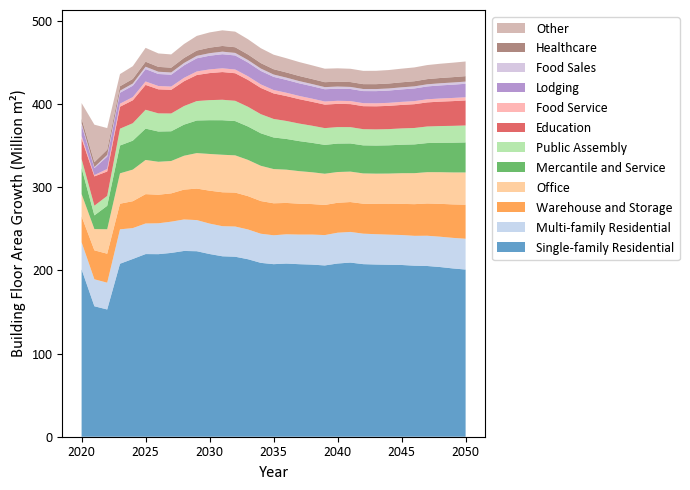

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Standardize dictionary keys (to ensure exact matching)
columns_to_plot = {
    'RMI_single_family_growth_million_m2': 'Single-family Residential',
    'RMI_multifamily_growth_million_m2': 'Multi-family Residential',
    'RMI_warehouse and storage_growth_million_m2': 'Warehouse and Storage',
    'RMI_office_growth_million_m2': 'Office',
    'RMI_mercantile_service_growth_million_m2': 'Mercantile and Service',
    'RMI_public assembly_growth_million_m2': 'Public Assembly',
    'RMI_education_growth_million_m2': 'Education',
    'RMI_food service_growth_million_m2': 'Food Service',
    'RMI_lodging_growth_million_m2': 'Lodging',
    'RMI_food sales_growth_million_m2': 'Food Sales',
    'RMI_healthcare_growth_million_m2': 'Healthcare',
    'RMI_other_growth_million_m2': 'Other'
}

# Filter the dataframe for years 2025 to 2050 and rename columns
years = list(range(2020, 2051))
filtered_df = rmi_projections[rmi_projections['year'].isin(years)][['year'] + list(columns_to_plot.keys())]
filtered_df = filtered_df.rename(columns=columns_to_plot).set_index('year')

# Define colors for each category
colors = plt.get_cmap('tab20').colors[:len(columns_to_plot)]

# Create the plot
plt.figure(figsize=(7, 5))
plt.stackplot(filtered_df.index, filtered_df.T, labels=columns_to_plot.values(), colors=colors, alpha=0.7)

# Customize the plot
plt.title('', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Building Floor Area Growth (Million m²)', fontsize=12)

# Reverse legend order
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], loc='upper left', bbox_to_anchor=(1.0, 1.0), fontsize=10)

# Set x-axis ticks to every 5 years from 2025 to 2050
plt.xticks(range(2020, 2051, 5), rotation=0)

plt.grid(False)
plt.tight_layout()
plt.show()


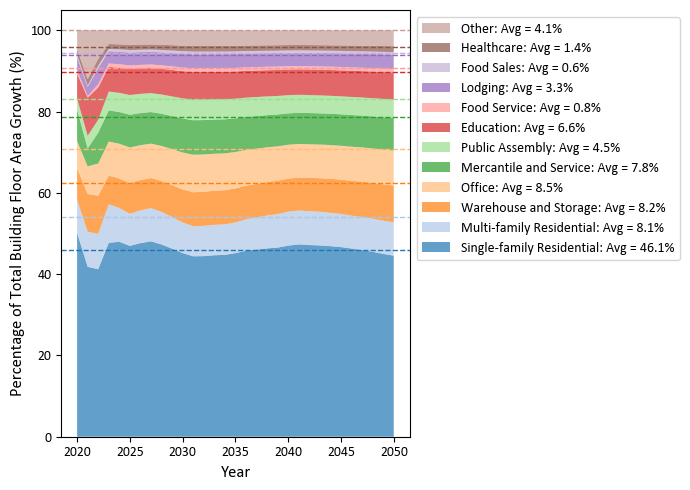

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter the dataframe for years 2020 to 2050 and select specific columns
years = list(range(2020, 2051))
columns_to_plot = {
    'RMI_single_family_growth_million_m2': 'Single-family Residential',
    'RMI_multifamily_growth_million_m2': 'Multi-family Residential',
    'RMI_warehouse and storage_growth_million_m2': 'Warehouse and Storage',
    'RMI_office_growth_million_m2': 'Office',
    'RMI_mercantile_service_growth_million_m2': 'Mercantile and Service',
    'RMI_public assembly_growth_million_m2': 'Public Assembly',
    'RMI_education_growth_million_m2': 'Education',
    'RMI_food service_growth_million_m2': 'Food Service',
    'RMI_lodging_growth_million_m2': 'Lodging',
    'RMI_food sales_growth_million_m2': 'Food Sales',
    'RMI_healthcare_growth_million_m2': 'Healthcare',
    'RMI_other_growth_million_m2': 'Other'
}

# Filter the dataframe and rename columns
filtered_df = rmi_projections[rmi_projections['year'].isin(years)][['year'] + list(columns_to_plot.keys())]
filtered_df = filtered_df.rename(columns=columns_to_plot).set_index('year')

# Normalize data to get percentages for each year (100% stacked)
filtered_df_percent = filtered_df.div(filtered_df.sum(axis=1), axis=0) * 100

# Define colors for each category
colors = plt.get_cmap('tab20').colors[:len(columns_to_plot)]

# Create the plot
plt.figure(figsize=(7, 5))
plt.stackplot(filtered_df_percent.index, filtered_df_percent.T, labels=columns_to_plot.values(), colors=colors, alpha=0.7)

# Calculate the average percentages
average_percentages = filtered_df_percent.mean()

# Add horizontal lines (cumulative average, but not used in legend)
cumulative_averages = filtered_df_percent.cumsum(axis=1).mean()
for i, col in enumerate(filtered_df_percent.columns):
    plt.axhline(y=cumulative_averages[col], color=colors[i], linestyle='--', linewidth=1)

# Customize the plot
plt.title('', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage of Total Building Floor Area Growth (%)', fontsize=12)

# Legend with average annotations
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = [f'{label}: Avg = {average_percentages[col]:.1f}%' for col, label in zip(filtered_df_percent.columns, labels)]
plt.legend(handles[::-1], new_labels[::-1], loc='upper left', bbox_to_anchor=(1.0, 1.0), fontsize=10)

# Set x-axis ticks to every 5 years from 2020 to 2050
plt.xticks(range(2020, 2051, 5), rotation=0)

# Remove gridlines and adjust layout
plt.grid(False)
plt.tight_layout()

# Show plot
plt.show()

In [54]:
import pandas as pd
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# Assuming rmi_projections is your original dataframe
floor_area = rmi_projections

# Transpose the dataframe, setting 'year' as the index
transposed_floor_area = floor_area.set_index('year').T

# Strip unnecessary whitespaces and clean column names
transposed_floor_area.index = transposed_floor_area.index.str.strip().str.replace(r"\\n", " ", regex=True)

# List the rows to sum (cleaned names)
rows_to_sum = [
    'RMI_mercantile_service_growth_million_m2',
    'RMI_food service_growth_million_m2',
    'RMI_lodging_growth_million_m2',
    'RMI_food sales_growth_million_m2',
    'RMI_other_growth_million_m2'
]

# Ensure the rows exist in the index before summing
existing_rows = [row for row in rows_to_sum if row in transposed_floor_area.index]

# Calculate the sum across specified rows for each year
transposed_floor_area.loc['RMI_other_CLF_category_growth_million_m2'] = transposed_floor_area.loc[existing_rows].sum()

# Inspect the result
transposed_floor_area.tail(20)


year,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
RMI_single_family_growth_million_m2,201.089366,156.793574,152.915339,207.897483,213.619292,219.511135,219.410366,220.903245,223.264748,222.931368,...,209.279124,207.409713,206.944953,206.652089,206.400422,205.553423,205.183540,203.933882,202.254657,200.902802
RMI_multifamily_growth_million_m2,32.652535,32.412584,32.220624,41.349520,37.110377,36.752592,37.099654,37.566172,37.831902,37.426215,...,36.856707,36.619931,36.455626,36.195631,36.022128,35.873506,36.359605,36.454334,36.739957,37.032943
RMI_warehouse and storage_growth_million_m2,31.051505,34.795282,34.813701,30.803162,32.320592,35.273785,34.315256,33.991847,35.868412,37.883201,...,35.908294,36.028490,36.349943,36.820791,37.405457,38.073173,38.782343,39.506419,40.223355,40.908963
RMI_office_growth_million_m2,26.864853,25.532433,29.387790,36.508553,37.973680,41.085013,39.624194,38.913825,40.711466,42.633047,...,36.569910,36.394938,36.423129,36.598045,36.881106,37.239591,37.631313,38.029865,38.413991,38.761052
RMI_mercantile_service_growth_million_m2,31.058407,16.474083,28.163054,33.420230,34.783051,37.656315,36.339926,35.710549,37.383321,39.171970,...,33.849385,33.708030,33.754747,33.937557,34.220897,34.574577,34.959529,35.351264,35.730032,36.074722
RMI_public assembly_growth_million_m2,11.075910,11.634850,11.915179,20.206193,20.979671,22.658141,21.813375,21.383792,22.331295,23.343055,...,19.581971,19.451087,19.428850,19.484594,19.597356,19.749463,19.918337,20.089924,20.252994,20.395669
RMI_education_growth_million_m2,24.374824,35.220522,29.354910,26.415892,27.544394,29.875502,28.885332,28.438705,29.827297,31.313875,...,27.701477,27.641374,27.735673,27.942508,28.233229,28.583399,28.961002,29.345903,29.721709,30.070767
RMI_food service_growth_million_m2,3.326991,1.522122,2.999189,3.671778,3.816896,4.127224,3.978160,3.904573,4.082582,4.272814,...,3.640160,3.620698,3.621463,3.636810,3.662882,3.696414,3.733211,3.770643,3.806610,3.838869
RMI_lodging_growth_million_m2,13.002289,8.495173,14.852519,13.090750,13.694424,14.901402,14.453892,14.276003,15.020764,15.819329,...,14.519331,14.531106,14.624034,14.776693,14.974410,15.204573,15.450383,15.701181,15.948210,16.181925
RMI_food sales_growth_million_m2,2.159967,1.206951,2.037316,2.510803,2.610062,2.822301,2.720394,2.670101,2.791860,2.921979,...,2.489661,2.476380,2.476931,2.487456,2.505316,2.528282,2.553478,2.579113,2.603746,2.625840


In [55]:
# Define the mapping dictionary based on the provided instructions
building_use_mapping = {
    "RMI_multifamily_growth_million_m2": "Residential: Multifamily (5 or more units)",
    "RMI_single_family_growth_million_m2": "Residential: Single-family",
    "RMI_office_growth_million_m2": "Office",
    "RMI_public assembly_growth_million_m2": "Public Assembly",
    "RMI_education_growth_million_m2": "Education",
    "RMI_healthcare_growth_million_m2": "Healthcare",
    "RMI_warehouse and storage_growth_million_m2": "Warehouse and Storage",
    "RMI_other_CLF_category_growth_million_m2": "Others"
    
}

# Add the building_use column using the mapping
transposed_floor_area["building_use"] = transposed_floor_area.index.map(building_use_mapping)

# Reorder columns to make building_use the second column
columns = ["building_use"] + [col for col in transposed_floor_area.columns if col != "building_use"]
transposed_floor_area = transposed_floor_area[columns]

transposed_floor_area.tail(18)

year,building_use,2020,2021,2022,2023,2024,2025,2026,2027,2028,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
RMI_single_family_growth_million_m2,Residential: Single-family,201.089366,156.793574,152.915339,207.897483,213.619292,219.511135,219.410366,220.903245,223.264748,...,209.279124,207.409713,206.944953,206.652089,206.400422,205.553423,205.183540,203.933882,202.254657,200.902802
RMI_multifamily_growth_million_m2,Residential: Multifamily (5 or more units),32.652535,32.412584,32.220624,41.349520,37.110377,36.752592,37.099654,37.566172,37.831902,...,36.856707,36.619931,36.455626,36.195631,36.022128,35.873506,36.359605,36.454334,36.739957,37.032943
RMI_warehouse and storage_growth_million_m2,Warehouse and Storage,31.051505,34.795282,34.813701,30.803162,32.320592,35.273785,34.315256,33.991847,35.868412,...,35.908294,36.028490,36.349943,36.820791,37.405457,38.073173,38.782343,39.506419,40.223355,40.908963
RMI_office_growth_million_m2,Office,26.864853,25.532433,29.387790,36.508553,37.973680,41.085013,39.624194,38.913825,40.711466,...,36.569910,36.394938,36.423129,36.598045,36.881106,37.239591,37.631313,38.029865,38.413991,38.761052
RMI_mercantile_service_growth_million_m2,NaN,31.058407,16.474083,28.163054,33.420230,34.783051,37.656315,36.339926,35.710549,37.383321,...,33.849385,33.708030,33.754747,33.937557,34.220897,34.574577,34.959529,35.351264,35.730032,36.074722
RMI_public assembly_growth_million_m2,Public Assembly,11.075910,11.634850,11.915179,20.206193,20.979671,22.658141,21.813375,21.383792,22.331295,...,19.581971,19.451087,19.428850,19.484594,19.597356,19.749463,19.918337,20.089924,20.252994,20.395669
RMI_education_growth_million_m2,Education,24.374824,35.220522,29.354910,26.415892,27.544394,29.875502,28.885332,28.438705,29.827297,...,27.701477,27.641374,27.735673,27.942508,28.233229,28.583399,28.961002,29.345903,29.721709,30.070767
RMI_food service_growth_million_m2,NaN,3.326991,1.522122,2.999189,3.671778,3.816896,4.127224,3.978160,3.904573,4.082582,...,3.640160,3.620698,3.621463,3.636810,3.662882,3.696414,3.733211,3.770643,3.806610,3.838869
RMI_lodging_growth_million_m2,NaN,13.002289,8.495173,14.852519,13.090750,13.694424,14.901402,14.453892,14.276003,15.020764,...,14.519331,14.531106,14.624034,14.776693,14.974410,15.204573,15.450383,15.701181,15.948210,16.181925
RMI_food sales_growth_million_m2,NaN,2.159967,1.206951,2.037316,2.510803,2.610062,2.822301,2.720394,2.670101,2.791860,...,2.489661,2.476380,2.476931,2.487456,2.505316,2.528282,2.553478,2.579113,2.603746,2.625840


In [56]:
# Extract the column names from transposed_floor_area, excluding "building_use"
new_columns = [col for col in transposed_floor_area.columns if col != "building_use"]

# Add the new columns to the material_intensity_building_use_list dataframe with NaN values initially
for col in new_columns:
    material_intensity_building_use_list[col] = pd.NA

# Display the updated material_intensity_building_use_list dataframe to check the result
material_intensity_building_use_list.head()


,mat_type,mat_group,metric,filter,building_use,measure,value,2020,2021,2022,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,Acoustic ceiling tile aluminum,Acoustic ceilings,gwp_intensity_kg_per_m2_excluding_bio,No Filter,Others,mean,0.939156,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,Acoustic ceiling tile fiber,Acoustic ceilings,gwp_intensity_kg_per_m2_excluding_bio,No Filter,Others,mean,0.885480,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,Acoustic ceiling tile steel,Acoustic ceilings,gwp_intensity_kg_per_m2_excluding_bio,No Filter,Others,mean,0.612354,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,Acoustic ceilings - other,Acoustic ceilings,gwp_intensity_kg_per_m2_excluding_bio,No Filter,Others,mean,0.732969,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,Adhesives and sealants,Adhesives and sealants,gwp_intensity_kg_per_m2_excluding_bio,No Filter,Others,mean,0.393866,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [57]:
# Filter the material_intensity_building_use_list to include only rows where 'filter' is 'No Filter'
material_intensity_building_use_list = material_intensity_building_use_list[
    material_intensity_building_use_list['filter'] == 'No Filter'
]

# Convert year columns to strings if they are in numeric format
transposed_floor_area.columns = transposed_floor_area.columns.astype(str)

# Extract list of years from 2020 to 2050 for calculation columns
years = [str(year) for year in range(2020, 2051)]

# Prepare lists to store calculation results
material_intensity_results = []
gwp_intensity_results = []

# Iterate over each material category in material_intensity_building_use_list
for material_category, group in material_intensity_building_use_list.groupby("mat_type"):
    for _, row in group.iterrows():
        building_use = row['building_use']
        mat_group = row['mat_group']  # Extract the mat_group value
        
        # Ensure we're only using rows where measure is 'mean'
        if row['measure'] != 'mean':
            continue
        
        # Find matching row in transposed_floor_area
        floor_area_row = transposed_floor_area[transposed_floor_area['building_use'] == building_use]
        
        if not floor_area_row.empty:
            # Extract floor area values for the years (convert to numeric, ignore errors for NaNs)
            floor_area_values = floor_area_row[years].astype(float).values.flatten()
            
            # Calculate 'material_intensity_kg_per_m2' by multiplying mean with floor area values
            if row['metric'] == 'material_intensity_kg_per_m2':
                material_intensity_kg_per_m2 = (row['value'] * floor_area_values * 1000).tolist()
                material_intensity_results.append([material_category, mat_group, building_use] + material_intensity_kg_per_m2)
            
            # Calculate 'gwp_intensity_kg_per_m2_excluding_bio' by multiplying mean with floor area values
            elif row['metric'] == 'gwp_intensity_kg_per_m2_excluding_bio':
                gwp_intensity_kg_per_m2_excluding_bio = (row['value'] * floor_area_values * 1000).tolist()
                gwp_intensity_results.append([material_category, mat_group, building_use] + gwp_intensity_kg_per_m2_excluding_bio)

# Convert results to DataFrames and include 'mat_group' in the columns
material_intensity_df = pd.DataFrame(
    material_intensity_results, 
    columns=['mat_type', 'mat_group', 'building_use'] + years
)

gwp_intensity_df = pd.DataFrame(
    gwp_intensity_results, 
    columns=['mat_type', 'mat_group', 'building_use'] + years
)

# Display the resulting dataframes for verification
material_intensity_df.head()
gwp_intensity_df.head()


,mat_type,mat_group,building_use,2020,2021,2022,2023,2024,2025,2026,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,Acoustic ceiling tile aluminum,Acoustic ceilings,Others,64043.205442,68309.967152,69544.224543,63270.658017,65965.897680,71540.013725,69160.345454,...,66174.675691,66019.271696,66232.424600,66713.980240,67395.382992,68218.187878,69105.949738,70010.535746,70892.857140,71710.827327
1,Acoustic ceiling tile aluminum,Acoustic ceilings,Education,62797.329477,90739.309395,75627.620020,68055.770517,70963.152588,76968.832539,74417.838483,...,71367.848320,71213.004563,71455.947742,71988.821552,72737.812191,73639.960503,74612.787657,75604.416281,76572.611092,77471.897434
2,Acoustic ceiling tile aluminum,Acoustic ceilings,Healthcare,3510.555172,3646.842662,3893.699350,3278.949326,3429.747241,3731.600072,3619.124828,...,3630.385123,3633.049722,3656.008991,3693.903533,3743.062361,3800.331549,3861.509841,3923.931710,3985.411647,4043.563343
3,Acoustic ceiling tile aluminum,Acoustic ceilings,Office,37977.198357,36093.637405,41543.720338,51609.907865,53681.067103,58079.369429,56014.298594,...,51696.644550,51449.297010,51489.148996,51736.416584,52136.562539,52643.330740,53197.084881,53760.492342,54303.508579,54794.127628
4,Acoustic ceiling tile aluminum,Acoustic ceilings,Public Assembly,17392.554926,18270.260607,18710.463502,31729.882120,32944.477820,35580.188069,34253.647590,...,30749.662838,30544.136109,30509.215909,30596.751160,30773.822915,31012.677012,31277.859822,31547.303809,31803.373370,32027.417550


In [58]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np
# from matplotlib.ticker import PercentFormatter


# # --- Prep function ---
# def prep(df):
#     df = df.copy()
#     df.columns = df.columns.astype(str)
#     years = [str(y) for y in range(2020, 2051)]
#     df = df[['mat_group'] + years]
#     g = df.groupby('mat_group').sum().reset_index()
#     T = g.set_index('mat_group').transpose()
#     T.index = T.index.astype(int)
#     T.index.name = 'year'
#     return T

# mass = prep(material_intensity_df)         # tons
# co2e = prep(gwp_intensity_df)              # ton CO2e

# # --- Determine stack order based on total material consumption ---
# total_mass = mass.sum(axis=0)
# cats_sorted = total_mass.sort_values(ascending=False).index.tolist()

# # palette
# palette = [
#     "#6b8ba4", "#f4a261", "#86c89a", "#e76f51", "#b39ddb", "#a1887f",
#     "#f7aac3", "#a3a3a3", "#d4cd6a", "#66c2cd", "#ffa07a", "#7ea9cc",
#     "#9cc5b0", "#8db600", "#f4c542", "#d86a78", "#bb88b4", "#ffb3c1",
#     "#a67b5b", "#c4c4c4", "#b0c72c", "#4682b4"
# ] * 3
# color_map = {c: palette[i] for i, c in enumerate(cats_sorted)}

# plt.rcParams['font.family'] = 'Arial'

# # Build absolute arrays
# years_x = mass.index
# data_top_abs = [mass[cat].values / 1_000_000 for cat in cats_sorted if cat in mass.columns]
# data_bot_abs = [co2e[cat].values / 1_000_000 for cat in cats_sorted if cat in co2e.columns]
# colors = [color_map[cat] for cat in cats_sorted if cat in mass.columns]
# labels = [cat for cat in cats_sorted if cat in mass.columns]

# # Build average percent arrays (single constant series for each category)
# arr_mass = np.vstack([mass[cat].values for cat in cats_sorted if cat in mass.columns])
# avg_mass = arr_mass.mean(axis=1)
# avg_mass_share = avg_mass / avg_mass.sum() * 100
# data_top_pct = [np.repeat(val, len(years_x)) for val in avg_mass_share]

# arr_co2e = np.vstack([co2e[cat].values for cat in cats_sorted if cat in co2e.columns])
# avg_co2e = arr_co2e.mean(axis=1)
# avg_co2e_share = avg_co2e / avg_co2e.sum() * 100
# data_bot_pct = [np.repeat(val, len(years_x)) for val in avg_co2e_share]

# fig, axes = plt.subplots(
#     2, 2, figsize=(6.5, 9),
#     sharex=True,
#     gridspec_kw={'hspace': 0.08, 'wspace': 0.08, 'height_ratios': [1, 1], 'width_ratios': [1.8, 0.2]}
# )

# # Left column, absolute
# ax00 = axes[0, 0]
# ax10 = axes[1, 0]

# ax00.set_axisbelow(True)
# ax00.grid(axis='y', color='white')
# ax00.stackplot(years_x, data_top_abs, labels=labels, colors=colors, alpha=1)
# ax00.set_ylabel("Material Consumption\n(Million Metric Tons)", color='black')
# ax00.set_xlim(2020, 2050)

# ax10.set_axisbelow(True)
# ax10.grid(axis='y', color='white')
# ax10.stackplot(years_x, data_bot_abs, labels=labels, colors=colors, alpha=1)
# ax10.set_ylabel("Embodied Carbon\n(Million Metric Tons $\mathrm{CO}_2\mathrm{e}$)", color='black')
# ax10.set_xticks(np.arange(2020, 2051, 5))
# ax10.set_xlabel("Year", color='black')

# # Right column, average percent contributions
# ax01 = axes[0, 1]
# ax11 = axes[1, 1]

# ax01.set_axisbelow(True)
# ax01.grid(axis='y', color='white')
# ax01.stackplot(years_x, data_top_pct, colors=colors, alpha=1)
# ax01.set_ylim(0, 100)
# ax01.set_yticks([0, 20, 40, 60, 80, 100])
# ax01.set_xlim(2020, 2050)
# # Remove x-axis ticks for top right and bottom right graphs
# ax01.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
# ax01.yaxis.set_major_formatter(PercentFormatter(xmax=100))
# ax01.yaxis.tick_right()
# ax01.yaxis.set_label_position("right")

# ax11.set_axisbelow(True)
# ax11.grid(axis='y', color='white')
# ax11.stackplot(years_x, data_bot_pct, colors=colors, alpha=1)
# ax11.set_ylim(0, 100)
# ax11.set_yticks([0, 20, 40, 60, 80, 100])
# ax11.set_xticks(np.arange(2020, 2051, 5))
# #ax11.set_xlabel("Average\nContributions", color='black')
# ax11.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
# ax11.yaxis.set_major_formatter(PercentFormatter(xmax=100))
# ax11.yaxis.tick_right()
# ax11.yaxis.set_label_position("right")

# # One legend for all, same reversed order
# handles, labels_leg = ax00.get_legend_handles_labels()
# handles = handles[::-1]
# labels_leg = labels_leg[::-1]
# fig.legend(handles, labels_leg, loc='center left', bbox_to_anchor=(0.95, 0.5), frameon=False)

# plt.tight_layout()
# plt.subplots_adjust(right=0.88, hspace=0.05, wspace=0.15)
# fig.savefig("./Image Exports/Fig.7.Projections_by_mat_group_mui_order.png", dpi=600, bbox_inches="tight", pad_inches=0.1)
# plt.show()


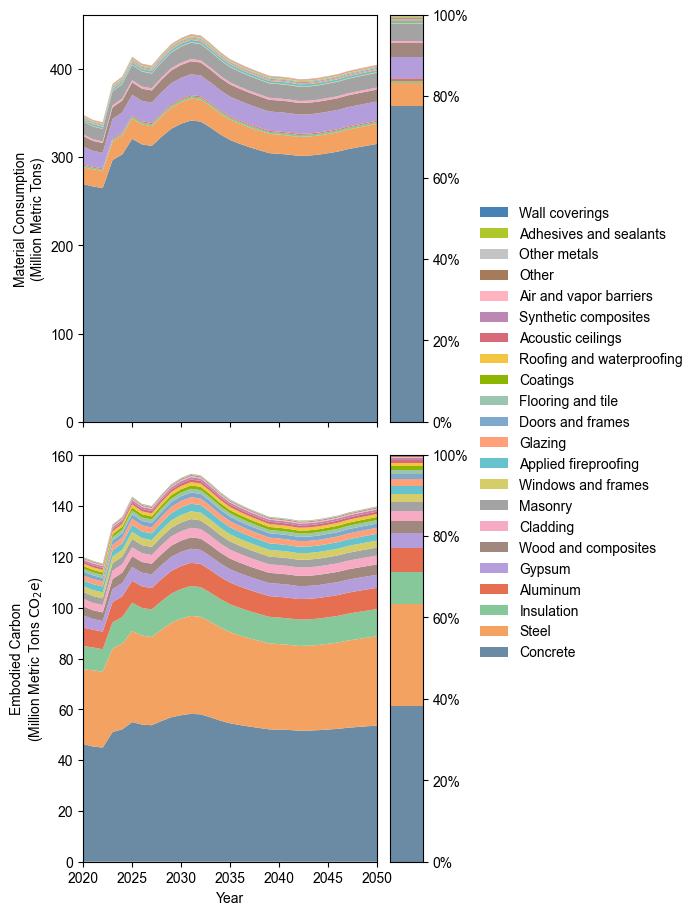

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

# --- Prep function ---
def prep(df):
    df = df.copy()
    df.columns = df.columns.astype(str)
    years = [str(y) for y in range(2020, 2051)]
    df = df[['mat_group'] + years]
    g = df.groupby('mat_group').sum().reset_index()
    T = g.set_index('mat_group').transpose()
    T.index = T.index.astype(int)
    T.index.name = 'year'
    return T

mass = prep(material_intensity_df)         # tons
co2e = prep(gwp_intensity_df)              # ton CO2e

# --- Determine stack order based on average embodied carbon contribution ---
avg_ec_by_cat = co2e.mean(axis=0)  # average across years per category
cats_sorted = avg_ec_by_cat.sort_values(ascending=False).index.tolist()

# palette
palette = [
    "#6b8ba4", "#f4a261", "#86c89a", "#e76f51", "#b39ddb", "#a1887f",
    "#f7aac3", "#a3a3a3", "#d4cd6a", "#66c2cd", "#ffa07a", "#7ea9cc",
    "#9cc5b0", "#8db600", "#f4c542", "#d86a78", "#bb88b4", "#ffb3c1",
    "#a67b5b", "#c4c4c4", "#b0c72c", "#4682b4"
] * 3
color_map = {c: palette[i] for i, c in enumerate(cats_sorted)}

plt.rcParams['font.family'] = 'Arial'

# Build absolute arrays (ordered by avg EC)
years_x = mass.index
labels = [cat for cat in cats_sorted if cat in mass.columns]
colors = [color_map[cat] for cat in labels]
data_top_abs = [mass[cat].values / 1_000_000 for cat in labels]
data_bot_abs = [co2e[cat].values / 1_000_000 for cat in labels]

# Build average percent arrays, constant over time, ordered by avg EC
arr_mass = np.vstack([mass[cat].values for cat in labels])
avg_mass = arr_mass.mean(axis=1)
avg_mass_share = avg_mass / avg_mass.sum() * 100
data_top_pct = [np.repeat(val, len(years_x)) for val in avg_mass_share]

arr_co2e = np.vstack([co2e[cat].values for cat in labels])
avg_co2e = arr_co2e.mean(axis=1)
avg_co2e_share = avg_co2e / avg_co2e.sum() * 100
data_bot_pct = [np.repeat(val, len(years_x)) for val in avg_co2e_share]

fig, axes = plt.subplots(
    2, 2, figsize=(4.5, 11),
    sharex=True,
    gridspec_kw={'hspace': 0.08, 'wspace': 0.08, 'height_ratios': [1, 1], 'width_ratios': [1.8, 0.2]}
)

# Left column, absolute
ax00 = axes[0, 0]
ax10 = axes[1, 0]

ax00.set_axisbelow(True)
ax00.grid(axis='y', color='white')
ax00.stackplot(years_x, data_top_abs, labels=labels, colors=colors, alpha=1)
ax00.set_ylabel("Material Consumption\n(Million Metric Tons)", color='black')
ax00.set_xlim(2020, 2050)

ax10.set_axisbelow(True)
ax10.grid(axis='y', color='white')
ax10.stackplot(years_x, data_bot_abs, labels=labels, colors=colors, alpha=1)
ax10.set_ylabel("Embodied Carbon\n(Million Metric Tons $\mathrm{CO}_2\mathrm{e}$)", color='black')
ax10.set_xticks(np.arange(2020, 2051, 5))
ax10.set_xlabel("Year", color='black')

# Right column, average percent contributions
ax01 = axes[0, 1]
ax11 = axes[1, 1]

ax01.set_axisbelow(True)
ax01.grid(axis='y', color='white')
ax01.stackplot(years_x, data_top_pct, colors=colors, alpha=1)
ax01.set_ylim(0, 100)
ax01.set_yticks([0, 20, 40, 60, 80, 100])
ax01.set_xlim(2020, 2050)
ax01.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax01.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax01.yaxis.tick_right()
ax01.yaxis.set_label_position("right")

ax11.set_axisbelow(True)
ax11.grid(axis='y', color='white')
ax11.stackplot(years_x, data_bot_pct, colors=colors, alpha=1)
ax11.set_ylim(0, 100)
ax11.set_yticks([0, 20, 40, 60, 80, 100])
ax11.set_xticks(np.arange(2020, 2051, 5))
ax11.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax11.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax11.yaxis.tick_right()
ax11.yaxis.set_label_position("right")

# Legend matching stack order (bottom-to-top)
handles, labels_leg = ax00.get_legend_handles_labels()
handles = handles[::-1]
labels_leg = labels_leg[::-1]
fig.legend(handles, labels_leg, loc='center left', bbox_to_anchor=(0.98, 0.5), frameon=False)

plt.tight_layout()
plt.subplots_adjust(right=0.88, hspace=0.05, wspace=0.15)
fig.savefig("./Image Exports/Fig.7.Projections_by_mat_group_eci_order.png", dpi=600, bbox_inches="tight", pad_inches=0.1)
plt.show()


Figure saved at: ./Image Exports/Fig.6.Projections_by_building_use_eci_order.png


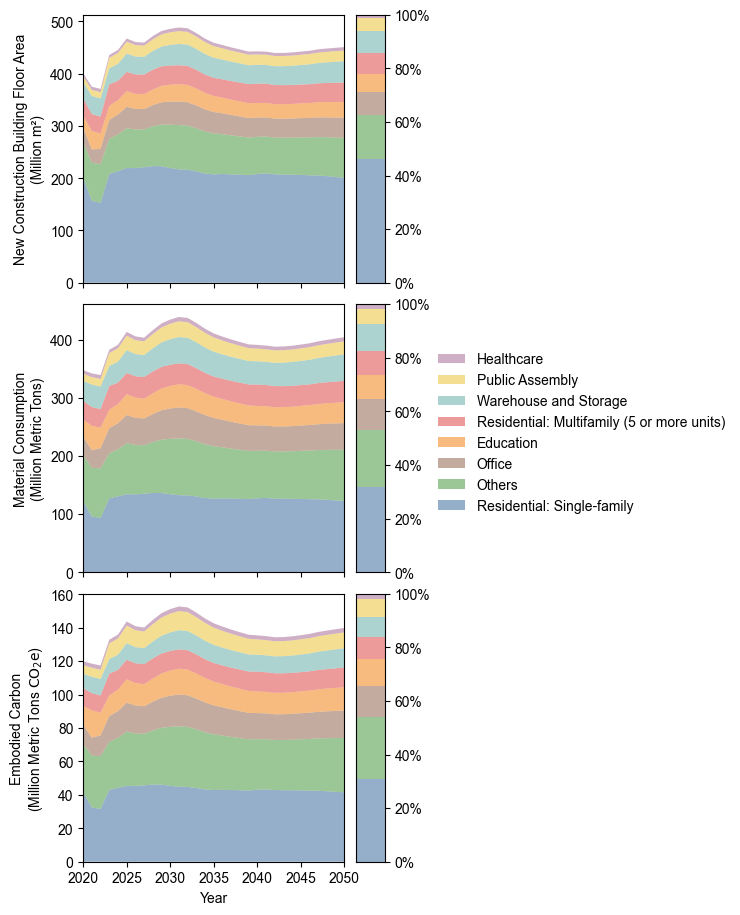

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import PercentFormatter
import numpy as np

# ---------- PREPARE DATA ----------
column_mapping = {
    "RMI_multifamily_growth_million_m2": "Residential: Multifamily (5 or more units)",
    "RMI_single_family_growth_million_m2": "Residential: Single-family",
    "RMI_office_growth_million_m2": "Office",
    "RMI_public assembly_growth_million_m2": "Public Assembly",
    "RMI_education_growth_million_m2": "Education",
    "RMI_healthcare_growth_million_m2": "Healthcare",
    "RMI_warehouse and storage_growth_million_m2": "Warehouse and Storage",
    "RMI_mercantile_service_growth_million_m2": "Others",
    "RMI_food service_growth_million_m2": "Others",
    "RMI_food sales_growth_million_m2": "Others",
    "RMI_lodging_growth_million_m2": "Others",
    "RMI_other_growth_million_m2": "Others"
}
years = list(range(2020, 2051))
selected_cols = ['year'] + list(column_mapping.keys())
filtered_df = rmi_projections[rmi_projections['year'].isin(years)][selected_cols].copy()
renamed_df = filtered_df.rename(columns=column_mapping)
top_df = renamed_df.drop(columns='year').groupby(level=0, axis=1).sum()
top_df['year'] = filtered_df['year'].values
top_df = top_df.set_index('year').sort_index()

def reshape_building_use(df_wide):
    df_wide = df_wide.copy()
    df_wide.columns = df_wide.columns.astype(str)
    cols = ['building_use'] + [str(y) for y in years]
    df_wide = df_wide[cols]
    g = df_wide.groupby('building_use').sum()
    g = g.transpose()
    g.index = g.index.astype(int)
    g = g.loc[years]
    return g

mid_df = reshape_building_use(material_intensity_df)         # tons
bot_df = reshape_building_use(gwp_intensity_df)              # tons CO2e

# ---------- ORDER BY AVERAGE EC ----------
def avg_percent(df):
    col_means = df.mean(axis=0)
    total = col_means.sum()
    shares = (col_means / total * 100.0).fillna(0.0)
    return shares

bot_avg_share = avg_percent(bot_df)  # basis for ordering
cats_order = bot_avg_share.sort_values(ascending=False).index.tolist()

def apply_order(df, order):
    base = [c for c in order if c in df.columns]
    extras = [c for c in df.columns if c not in base]
    return df[base + extras]

# Reorder absolute-value dataframes by EC-based order
top_df = apply_order(top_df, cats_order)
mid_df = apply_order(mid_df, cats_order)
bot_df = apply_order(bot_df, cats_order)

# Average percent shares for right column, ordered by EC-based order
top_avg = avg_percent(top_df).reindex(top_df.columns, fill_value=0.0)
mid_avg = avg_percent(mid_df).reindex(mid_df.columns, fill_value=0.0)
bot_avg = avg_percent(bot_df).reindex(bot_df.columns, fill_value=0.0)

def constant_series_for_stackplot(shares, index_years):
    return [np.repeat(shares[c], len(index_years)) for c in shares.index]

# ---------- COLOR PALETTE ----------
base_colors = [
    "#4e79a7", "#59a14f", "#9c755f", "#f28e2b", "#e15759",
    "#76b7b2", "#edc948", "#af7aa1", "#ff9da7", "#bab0ac",
    "#86bcb6", "#d37295"
] * 3
ordered_cats = list(top_df.columns)  # same order applied to all
color_map = {c: base_colors[i] for i, c in enumerate(ordered_cats)}

def hex_to_rgba(hex_color, alpha):
    rgb = mcolors.to_rgb(hex_color)
    return (rgb[0], rgb[1], rgb[2], alpha)

# ---------- PLOT ----------
plt.rcParams["font.family"] = "Arial"
plt.rcParams["text.color"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"

fig, axes = plt.subplots(
    3, 2, figsize=(4, 11), sharex='col',
    gridspec_kw={'height_ratios': [1, 1, 1], 'width_ratios': [1.8, 0.2], 'wspace': 0.08, 'hspace': 0.08}
)

def add_stack(ax, df, ylabel, alpha=0.6):
    cats = df.columns.tolist()
    colors = [hex_to_rgba(color_map[c], alpha) for c in cats]
    ax.stackplot(df.index, df.T, labels=cats, colors=colors, zorder=2)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', color='white', zorder=1)
    ax.grid(axis='x', visible=False)
    ax.set_xlim(df.index.min(), df.index.max())

# Left column, absolute values
add_stack(axes[0, 0], top_df, "New Construction Building Floor Area\n(Million m²)")
add_stack(axes[1, 0], mid_df / 1e6, "Material Consumption\n(Million Metric Tons)")
add_stack(axes[2, 0], bot_df / 1e6, "Embodied Carbon\n(Million Metric Tons $\\mathrm{CO}_2\\mathrm{e}$)")

# Right column, average percent contributions as constant stacks
def add_avg_percent_stack(ax, shares, years_index, ylabel):
    cats = list(shares.index)
    colors = [hex_to_rgba(color_map[c], 0.6) for c in cats]
    const_series = constant_series_for_stackplot(shares, years_index)
    ax.stackplot(years_index, const_series, labels=cats, colors=colors, zorder=2)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    ax.grid(axis='y', color='white', zorder=1)
    ax.grid(axis='x', visible=False)
    ax.set_xlim(min(years_index), max(years_index))
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

add_avg_percent_stack(axes[0, 1], top_avg, top_df.index, "")
add_avg_percent_stack(axes[1, 1], mid_avg, mid_df.index, "")
add_avg_percent_stack(axes[2, 1], bot_avg, bot_df.index, "")

# Bottom x-axis formatting, left column only
axes[2, 0].set_xticks(range(2020, 2051, 5))
axes[2, 0].set_xlabel("Year")

# Legend from left-top axes, preserving EC-based order
handles, labels = axes[0, 0].get_legend_handles_labels()

# Reverse so the legend matches stackplot's bottom-to-top visual order
handles = handles[::-1]
labels = labels[::-1]

fig.legend(handles, labels,
           loc='center left',
           bbox_to_anchor=(0.98, 0.5),
           frameon=False)

plt.tight_layout()
plt.subplots_adjust(right=0.88, hspace=0.05, wspace=0.15)

save_path = "./Image Exports/Fig.6.Projections_by_building_use_eci_order.png"
fig.savefig(save_path, dpi=600, bbox_inches="tight", pad_inches=0.1)
print(f"Figure saved at: {save_path}")

plt.show()


Cumulative.

In [63]:
# Calculate cumulative totals across all building uses from 2020 to 2050
total_floor_area_million_m2 = top_df.sum().sum()  # already in million m²
total_material_million_tons = mid_df.sum().sum() / 1e6  # convert tons to million tons
total_gwp_million_tons_co2e = bot_df.sum().sum() / 1e6  # convert tons CO₂e to million tons CO₂e

print("Total Floor Area (2020–2050):", round(total_floor_area_million_m2, 3), "million m²")
print("Total Material Use (2020–2050):", round(total_material_million_tons, 3), "million tons")
print("Total Embodied Carbon (2020–2050):", round(total_gwp_million_tons_co2e, 3), "million tons CO₂e")


Total Floor Area (2020–2050): 13914.593 million m²
Total Material Use (2020–2050): 12367.4 million tons
Total Embodied Carbon (2020–2050): 4288.869 million tons CO₂e


## Projection data extraction

### Mass and carbon stocks

In [61]:
import pandas as pd

# Function to prepare and export data for material or carbon stock projection
def prepare_and_export_table_format(df, output_file):
    # Ensure year columns are string formatted and filter to years 2020-2050
    df.columns = df.columns.astype(str)
    df = df[['mat_type'] + [str(year) for year in range(2020, 2051)]]

    # Group by material category and sum
    df_grouped = df.groupby('mat_type').sum().reset_index()

    # Export the data to a CSV file
    df_grouped.to_csv(output_file, index=False)
    print(f"Exported table format data to {output_file}")

# Prepare and export material stock projection data in table format
prepare_and_export_table_format(
    material_intensity_df,
    output_file='./Output Data/material_stock_projection_by_building_use_type.csv'
)

# Prepare and export carbon stock projection data in table format
prepare_and_export_table_format(
    gwp_intensity_df,
    output_file='./Output Data/carbon_stock_projection_by_building_use_type.csv'
)


Exported table format data to ./Output Data/material_stock_projection_by_building_use_type.csv
Exported table format data to ./Output Data/carbon_stock_projection_by_building_use_type.csv
